In [121]:
from IPython.display import display, HTML

display(HTML('<div style="font-size:5em; font-weight:bold; text-align:center;">Sparse-Cost-Robust-Learning <br> Cost-sensitive reweighting method to leverage sparse cost</div>'))


## Make sure to instal the following:  
Installation Commands for macOS \
\ ---------------------------------------   \ 
   \
conda create -n ds-env python=3.10  \
conda activate ds-env

conda install -c conda-forge \
pandas \
numpy \
matplotlib \
seaborn \
scikit-learn \
jupyter \
torchvision \
tqdm \
xgboost \
xlrd

pip install category_encoders  \
\ ---------------------------------------   \ 


# Setup: import and parameters

In [122]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
from tqdm import tqdm
import IPython
import gc
import matplotlib
matplotlib.rcParams.update({'errorbar.capsize': 5})

%matplotlib inline
%load_ext autoreload
%autoreload 2

!pip install category_encoders
from category_encoders import woe
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
def set_stantard_experiment_parameters(): # not really used any longuer but can be used to setup initial standard parameters

  data_set = 'Kaggle_Telco_Customer_Churn'   # Kaggle_Telco_Customer_Churn, tv_subscription_churn, kdd98, Kaggle_Credit_Card_Fraud and others (see below)
  print_details = True
  hyperparameters = {
      'lr' : 1e-3,
      'momentum' : 0.9,
      'batch_size' : 256,
      'num_iterations' : 10000,
      'weight_decay': 1e-5
  }
  # Ratio
  testingRatio = 0.1
  validationRatio = 0.1


# Adding Noise to the training data

In [124]:
import torch
import random

def add_label_noise(data_loader, training_noise):
    """
    Flips the labels of a proportion of the training data.
    """
    
    #print("training_noise in add_label_noise:",training_noise)
    if not (0 <= training_noise <= 1):
        raise ValueError("training_noise must be between 0 and 1.")

    all_features = []
    all_labels = []

    # Collecting all data into memory
    for feature_batch, label_batch in data_loader:
        all_features.append(feature_batch)
        all_labels.append(label_batch)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)

    # Computing how many labels to flip
    total_samples = labels.size(0)
    num_noisy = int(training_noise * total_samples)

    # Randomly choosing indices to flip
    indices_to_flip = random.sample(range(total_samples), num_noisy)

    # Flipping binary labels (0 ↔ 1)
    labels[indices_to_flip] = 1 - labels[indices_to_flip]

    return list(zip(features, labels))

In [125]:
import torch
import random

def add_label_noise_with_cost(data_loader, training_noise):
    """
    Flips the labels of a proportion of the training data, preserving cost matrices.
    """

    #print("training_noise in add_label_noise_with_cost:",training_noise)

    if not (0 <= training_noise <= 1):
        raise ValueError("training_noise must be between 0 and 1.")

    all_features = []
    all_labels = []
    all_costs = []

    # Collecting all data into memory
    for feature_batch, label_batch, cost_batch in data_loader:
        all_features.append(feature_batch)
        all_labels.append(label_batch)
        all_costs.append(cost_batch)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)
    costs = torch.cat(all_costs)

    # Computing how many labels to flip
    total_samples = labels.size(0)
    num_noisy = int(training_noise * total_samples)

    # Randomly choosing indices to flip
    indices_to_flip = random.sample(range(total_samples), num_noisy)

    # Flipping binary labels (0 ↔ 1)
    labels[indices_to_flip] = 1 - labels[indices_to_flip]

    return list(zip(features, labels, costs))


In [126]:
def get_noisy_dataloader(data_loader, training_noise):
  noisy_data = add_label_noise(data_loader, training_noise)
  features, labels = zip(*noisy_data)
  dataset = TensorDataset(torch.stack(features), torch.tensor(labels))
  noisy_loader = DataLoader(dataset, batch_size=hyperparameters['batch_size'], shuffle=True)

  return noisy_loader

def get_noisy_dataloader_with_cost(data_loader, training_noise):

    noisy_data = add_label_noise_with_cost(data_loader, training_noise)
    features, labels, costs = zip(*noisy_data)

    dataset = TensorDataset(
        torch.stack(features),
        torch.tensor(labels),
        torch.stack(costs)
    )

    noisy_loader = DataLoader(dataset, batch_size=hyperparameters['batch_size'], shuffle=True)

    return noisy_loader


# Dataset

Most of the code for the preprocessing is either inspired or taken directly from: 
Vanderschueren,T.,Verdonck,T.,Baesens,B.,&Verbeke,W. (2022). Predict-then-optimizeorpredict-
and-optimize? an empirical evaluation of cost-sensitive learning strategies. Information Sci-
ences, 594, 400-415. Retrievedfrom https://www.sciencedirect.com/science/article/pii/
S0020025522001542 doi: 

Github link: https://github.com/toonvds/CostSensitiveLearning 

### Functions for preprocessing

In [127]:
### Functions for preprocessing ###

# Calculate monthly payment (given credit line cl_i, interest rate int_ and number of terms n_term)
def calculate_a(cl_i, int_, n_term):
    """ Private function """
    return cl_i * ((int_ * (1 + int_) ** n_term) / ((1 + int_) ** n_term - 1))


# Calculate present value (of amount a given interest rate int_ and n_term number of terms)
def calculate_pv(a, int_, n_term):
    """ Private function """
    return a / int_ * (1 - 1 / (1 + int_) ** n_term)


# Calculate credit line Cl
def calculate_cl(k, inc_i, cl_max, debt_i, int_r, n_term):
    """ Private function """
    cl_k = k * inc_i  # k times monthly income
    A = calculate_a(cl_k, int_r, n_term)
    Cl_debt = calculate_pv(inc_i * min(A / inc_i, 1 - debt_i), int_r, n_term)
    return min(cl_k, cl_max, Cl_debt)


# Calculate cost of FN
def calculate_cost_fn(cl_i, lgd):
    return cl_i * lgd


# Calculate cost of FP
def calculate_cost_fp(cl_i, int_r, n_term, int_cf, pi_1, lgd, cl_avg):
    # Lost profit
    a = calculate_a(cl_i, int_r, n_term)
    pv = calculate_pv(a, int_cf, n_term)
    r = pv - cl_i

    # Profit of average customer
    r_avg = calculate_pv(calculate_a(cl_avg, int_r, n_term), int_cf, n_term) - cl_avg
    cost_fp = r - (1 - pi_1) * r_avg + pi_1 * calculate_cost_fn(cl_avg, lgd)
    return max(0, cost_fp)


# Apply functions to arrays
v_calculate_cost_fp = np.vectorize(calculate_cost_fp)
v_calculate_cost_fn = np.vectorize(calculate_cost_fn)
v_calculate_cl = np.vectorize(calculate_cl)

# Set variables/assumptions
k = 3
int_r = 0.0479 / 12
n_term = 24
int_cf = 0.0294 / 12
lgd = .75
cl_max = 25000



### Telco_customer_churn

In [128]:
def preprocess_telco_customer_churn(eda=False):
    try:
        telco_churn = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle_Telco_Customer_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

    except FileNotFoundError:
        telco_churn = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle_Telco_Customer_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

    # Drop customer ID
    telco_churn = telco_churn.drop('customerID', axis=1)

    # Drop observations with missing values
    telco_churn = telco_churn.replace('', np.nan)
    telco_churn = telco_churn.replace(' ', np.nan)
    telco_churn = telco_churn.dropna()

    # Get labels
    labels = (telco_churn['Churn'] == 'Yes').astype(int)
    telco_churn = telco_churn.drop('Churn', axis=1)

    # EDA
    if eda:
        for key in telco_churn.keys():
            plt.figure(key)
            plt.title(key)
            if not (key == 'TotalCharges'):
                markers, counts = np.unique(telco_churn[key], return_counts=True)
                plt.hist(markers, weights=counts)
            else:
                sns.kdeplot(telco_churn[key].astype(float))
            plt.show()

    # Convert categorical variables
    categorical_variables = [
        # 2 categories:
        'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling',
        # 3 or more categories:
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

    # Create the cost matrix based on Monthly Costs (Petrides and Verbeke, 2020)
    amounts = telco_churn['MonthlyCharges'].to_numpy()


    n_samples = amounts.shape[0]
    # print("\n\n ------------- n_samples in preprocess_telco_customer_churn: ")
    # print(n_samples)
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = 12 * amounts
    cost_matrix[:, 1, 0] = 2 * amounts
    cost_matrix[:, 1, 1] = 0

    # covariates = telco_churn.to_numpy()
    covariates = telco_churn
    labels = labels

    print("------ Kaggle_Telco_Customer_Churn correctly loaded ------ \n")
    if print_details:
      print("\n------ Data format loaded -  Kaggle_Telco_Customer_Churn ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n \n")

      # Info on cost_matrix
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)

      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))

      df = df.drop('MonthlyCharges', axis=1)

    return covariates, labels, amounts, cost_matrix, categorical_variables

### Tv_subscription_churn

In [129]:
def preprocess_tv_subscription_churn(eda=False):
    try:
        df = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/preprocess_tv_subscription_churn/churn_tv_subscriptions.csv.gz', delimiter=',', compression='gzip')
    except FileNotFoundError:
        df = pd.read_csv('../data/TV Subscription Churn/churn_tv_subscriptions.csv.gz', delimiter=',',
                         compression='gzip')

    # Drop ID
    df = df.drop('id', axis=1)

    # Get labels
    #labels = df['target'].to_numpy()
    labels = df['target']
    df = df.drop('target', axis=1)

    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # List categorical variables (none here)
    categorical_variables = []

    # Extract the cost matrix - based on Bahnsen et al. 2015
    n_samples = labels.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = df['C_TN']
    cost_matrix[:, 0, 1] = df['C_FN']
    cost_matrix[:, 1, 0] = df['C_FP']
    cost_matrix[:, 1, 1] = df['C_TP']

    clv = df['C_FN']

    df = df.drop(['C_TN', 'C_FN', 'C_FP', 'C_TP'], axis=1)

    # print("------ tv_subscription_churn correctly loaded ------ \n")
    # print("X shape:", X_data.shape)
    # print("Y shape:", Y_data.shape)
    # print("cost_matrix shape:", np.shape(cost_matrix))

    return df, labels, clv, cost_matrix, categorical_variables


### UCI Default of Credit Card Clients

In [130]:
def preprocess_default_credit_card(eda=False):
    try:
        df = pd.read_excel('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI Default of Credit Card Clients/default of credit card clients.xls', skiprows=[0])
    except FileNotFoundError:
        df = pd.read_excel('../data/UCI Default of Credit Card Clients/default of credit card clients.xls',skiprows=[0])

    # Drop id
    df = df.drop('ID', axis=1)

    # Get labels
    labels = df['default payment next month'].to_numpy()
    df = df.drop('default payment next month', axis=1)

    # EDA
    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # List categorical variables
    categorical_variables = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

    # Create the cost matrix based on Bahnsen  # Todo: ref
    credit_lines = df['LIMIT_BAL'].to_numpy()
    pi_1 = labels.mean()

    n_samples = credit_lines.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = v_calculate_cost_fn(credit_lines, lgd)
    cost_matrix[:, 1, 0] = v_calculate_cost_fp(credit_lines, int_r, n_term, int_cf, pi_1, lgd, credit_lines.mean())
    cost_matrix[:, 1, 1] = 0.0


    #df = df.drop('LIMIT_BAL', axis=1)
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()
    #credit_lines = pd.DataFrame(credit_lines)
    #cost_matrix = pd.DataFrame(cost_matrix)
    #categorical_variables = pd.DataFrame(categorical_variables)

    print("------ default_credit_card correctly loaded ------ \n")

    if print_details:
      print("\n------ Data format loaded -  default_credit_card ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n")
      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))
      print("-------------------------------------------------- \n \n")
      # Info on cost_matrix
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)

    return df, labels, credit_lines, cost_matrix, categorical_variables



### VUB Credit Scoring

In [131]:
def preprocess_vub_credit_scoring(eda=False):
    try:
        df = pd.read_excel('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/VUB Credit Scoring/anonymized_dataset.xlsx')
    except FileNotFoundError:
        df = pd.read_excel('../DATA/VUB Credit Scoring/anonymized_dataset.xlxs')

    # First instance has V1 as Days_late: delete
    df = df.drop(0)

    # Drop ID + original test set partitioning
    df = df.drop('ID', axis=1)
    df = df.drop(['Test_set1', 'Test_set2', 'Test_set3'], axis=1)
    # df = df[df['Business_channel'] == 3]

    # Get labels
    labels = (df['Default_45']).to_numpy().astype(int)
    df = df.drop(['Default_45', 'Days_late'], axis=1)

    # Todo: Set FICO_Score to average for missing values (see Petrides et al. 2020)
    df['FICO_Score'][df['FICO_Score'].isna()] = 0

    # EDA
    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # List categorical variables
    categorical_variables = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'Has_FICO', 'Business_channel']

    # Create the cost matrix based on Petrides et al. 2020
    amounts = df['Loan_amount'].to_numpy()

    # Todo: Allow negative costs?
    # Scale amounts such that they are all positive
    amounts = amounts - amounts.min() + 1e-9

    df = df.drop(['Expected_loss', 'Expected_profit'], axis=1)

    # Alternative: Bahnsen strategy
    pi_1 = labels.mean()

    n_samples = amounts.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = v_calculate_cost_fn(amounts, lgd)
    cost_matrix[:, 1, 0] = v_calculate_cost_fp(amounts, int_r, n_term, int_cf, pi_1, lgd, amounts.mean())
    cost_matrix[:, 1, 1] = 0.0

    df['V8'] = df['V8'].replace('>4', '5').astype(int)
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()

    if print_details:
      print("------ vub_credit_scoring correctly loaded ------ \n")
      print("X shape:", df.shape)
      print("Y shape:", labels.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))

    return df, labels, amounts, cost_matrix, categorical_variables

# df, labels, amounts, cost_matrix, categorical_variables = preprocess_vub_credit_scoring()
# print(df.info())
# print(df['V8'])


### KDD Cup 1998


In [132]:
def preprocess_kdd98(eda=False):
    try:
        kdd98train = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98LRN.txt', low_memory=False)
        kdd98val = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98VAL.txt', low_memory=False)
        kdd98val_labels = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/valtargt.txt', low_memory=False)
    except FileNotFoundError:
        kdd98train = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98LRN.txt', low_memory=False)
        kdd98val = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98VAL.txt', low_memory=False)
        kdd98val_labels = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/valtargt.txt', low_memory=False)

    # Attach kdd98val_labels to kdd98val
    kdd98val['CONTROLN'] = kdd98val_labels['CONTROLN']  # Unique ID
    kdd98val['TARGET_B'] = kdd98val_labels['TARGET_B']  # Donated yes/no
    kdd98val['TARGET_D'] = kdd98val_labels['TARGET_D']  # Donated amount

    # Merge train and val
    kdd98 = pd.concat([kdd98train, kdd98val])

    # Keep only subset of attributes - following Petrides and Verbeke (2020)
    selected_attributes = ['MAILCODE', 'NOEXCH', 'AGE', 'HOMEOWNR', 'NUMCHLD', 'INCOME', 'GENDER', 'WEALTH1',
                           'COLLECT1', 'CARDPROM', 'MAXADATE', 'CARDGIFT', 'MINRAMNT', 'MINRDATE', 'MAXRAMNT',
                           'MAXRDATE', 'LASTGIFT', 'LASTDATE', 'FISTDATE', 'NEXTDATE', 'TIMELAG', 'AVGGIFT',
                           'TARGET_D', 'TARGET_B']

    kdd98 = kdd98[selected_attributes]

    # Get amounts and labels
    amounts = kdd98['TARGET_D'].to_numpy()
    #labels = kdd98['TARGET_B'].to_numpy()
    labels = kdd98['TARGET_B']
    kdd98 = kdd98.drop(['TARGET_D', 'TARGET_B'], axis=1)

    # List categorical variables
    categorical_variables = ['MAILCODE', 'NOEXCH', 'HOMEOWNR', 'GENDER', 'COLLECT1', 'MAXADATE', 'MINRDATE', 'MAXRDATE',
                             'LASTDATE', 'FISTDATE', 'NEXTDATE']

    # Following Petrides and Verbeke, we use a linear regression to estimate amounts for people who did not donate
    # Rough prediction: leave out categorical variables + variables with any missing values
    from sklearn.linear_model import LinearRegression
    lin_reg = LinearRegression()
    x_temp = kdd98.drop(categorical_variables, axis=1)
    x_temp = x_temp.dropna(axis=1)
    lin_reg.fit(X=x_temp[labels == 1], y=amounts[labels == 1])
    est_amounts = lin_reg.predict(X=x_temp[labels == 0])
    amounts[labels == 0] = est_amounts

    # Cost matrix   Todo: Follow Petrides and Verbeke 2020?
    n_samples = amounts.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0  # Instead of 0.68  (no cost for contacting)
    cost_matrix[:, 0, 1] = amounts  # amounts[labels == 1].mean()  # Instead of 14.45 (no cost for contacting)
    cost_matrix[:, 1, 0] = 0.68
    cost_matrix[:, 1, 1] = 0.68

    print("------ kdd98 correctly loaded ------ \n")

    if print_details:
      print("\n------ Data format loaded -  kdd98 ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n")
      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))
      print("-------------------------------------------------- \n \n")

      # Info on cost_matrix
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)


    kdd98 = pd.DataFrame(kdd98)
    labels = pd.DataFrame(labels).squeeze()

    print("------ kaggle_ieee_fraud correctly loaded ------ \n")
    print("X shape:", kdd98.shape)
    print("Y shape:", labels.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("X_data:",type(kdd98))
    print("Y_data:",type(labels))
    print("amounts:",type(cost_matrix))


    # return covariates, labels, amounts, cost_matrix, categorical_variables
    return kdd98, labels, amounts, cost_matrix, categorical_variables





### Kaggle Credit Card Fraud

In [133]:
def preprocess_credit_card_data(fixed_cost, eda=False):
    """
    Load the Kaggle credit card dataset
    """
    try:
        creditcard = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle Credit Card Fraud/creditcard.csv')
    except FileNotFoundError:
        creditcard = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle Credit Card Fraud/creditcard.csv')

    # Preprocessing
    creditcard = creditcard[creditcard['Amount'] != 0]  # remove transactions with zero Amount
    creditcard = creditcard.drop('Time', axis=1)  # remove variable Time

    amounts = creditcard['Amount'].values
    labels = creditcard['Class']

    # Do not include log(amount)
    # creditcard['LogAmount'] = pd.Series(np.log(creditcard['Amount']))  # log-transformation of Amount

    cols = list(creditcard.columns)  # rearrange some columns - amount final column
    a, b = cols.index('Amount'), cols.index('Class')
    cols[b], cols[a] = cols[a], cols[b]
    creditcard = creditcard[cols]

    # covariates = np.array(creditcard.drop(['Class'], axis=1))
    covariates = creditcard.drop(['Class'], axis=1)

    # scaler = StandardScaler()
    # covariates_scaled = scaler.fit_transform(covariates)

    # Create cost matrix
    cost_matrix = np.zeros((len(covariates), 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = amounts
    cost_matrix[:, 1, 0] = fixed_cost
    cost_matrix[:, 1, 1] = fixed_cost

    covariates = creditcard.drop(['Amount'], axis=1)


    # Exploratory data analysis
    if eda:
        # 1. Cost distribution (per class)
        # Kernel density of amounts / logamounts
        fig, ax = plt.subplots(1, 2)
        sns.kdeplot(amounts[labels == 0], ax=ax[0])
        sns.kdeplot(amounts[labels == 1], ax=ax[0])
        ax[0].axvline(fixed_cost, 0, 1)
        # sns.kdeplot(amount, ax=ax[0])
        sns.kdeplot(np.log(amounts[labels == 0]), ax=ax[1])
        sns.kdeplot(np.log(amounts[labels == 1]), ax=ax[1])
        ax[1].axvline(np.log(fixed_cost), 0, 1)
        ax[0].set_xscale('log')
        ax[0].set_title('Amount')
        ax[1].set_title('Log(Amount)')
        ax[0].legend(['Negative', 'Positive'])
        ax[1].legend(['Negative', 'Positive'])

        fig.suptitle('Kernel density plots of transaction amounts')
        fig.show()

        # 2. t-SNE for two-dimensional representation (Total sample takes too long, so we use subsample of non-fraud cases)
        start = time.time()
        sample_size = 5000

        neg_indices = np.where(labels == 0)[0]
        sample_neg_indices = np.random.choice(neg_indices, size=sample_size).astype(np.int)
        pos_indices = np.where(labels == 1)[0]

        cov_sc_sample = np.concatenate((covariates[sample_neg_indices], covariates[pos_indices]))
        labels_sample = np.concatenate((labels[sample_neg_indices], labels[pos_indices]))
        amounts_sample = np.concatenate((amounts[sample_neg_indices], amounts[pos_indices]))

        tsne = TSNE(n_components=2, verbose=1, perplexity=9, n_iter=500)
        tsne_results = tsne.fit_transform(cov_sc_sample, labels_sample)

        fig2 = plt.figure()
        df_subset = pd.DataFrame()
        df_subset['tsne-2d-one'] = tsne_results[:, 0]
        df_subset['tsne-2d-two'] = tsne_results[:, 1]
        df_subset['y'] = labels_sample
        df_subset['amounts'] = amounts_sample
        sns.scatterplot(
            x="tsne-2d-one", y="tsne-2d-two",
            hue="y",
            palette=sns.color_palette("hls", 2),
            data=df_subset,
            legend="full",
            alpha=0.3,
            s=amounts_sample
        )
        fig2.show()
        end = time.time()
        print('Time elapsed = {}'.format(end - start))

    print("------ Kaggle_Credit_Card_Fraud correctly loaded ------ \n")
    if print_details:
      print("\n------ Data format loaded -  Kaggle_Credit_Card_Fraud ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n")
      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))
      print("amounts:", np.shape(amounts))
      print("categorical_variables shape:", np.shape(categorical_variables))
      print("-------------------------------------------------- \n \n")

      # Info on cost_matrix
      print("--  Info on cost_matrix  -- \n")
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)

    return covariates, labels, amounts, cost_matrix, []  # No categorical variables



### Kaggle give me some credit

In [134]:
def preprocess_give_me_some_credit():
    try:
        gmsc_train = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle Give Me Some Credit/cs-training.csv')
    except FileNotFoundError:
        gmsc_train = pd.read_csv('../data/Kaggle Give Me Some Credit/cs-training.csv')

    # Test set does not contain labels
    # gmsc_test = pd.read_csv('../data/Kaggle Give Me Some Credit/cs-test.csv')

    # Drop ID
    gmsc_train = gmsc_train.drop('Unnamed: 0', axis=1)

    # EDA: see https://www.kaggle.com/nicholasgah/eda-credit-scoring-top-100-on-leaderboard

    # Preprocessing follows Bahnsen et al 2014
    # https://github.com/albahnsen/CostSensitiveClassification/blob/master/costcla/datasets/base.py
    gmsc_train = gmsc_train.dropna()
    gmsc_train = gmsc_train.loc[(gmsc_train['MonthlyIncome'] > 0)]
    gmsc_train = gmsc_train.loc[(gmsc_train['DebtRatio'] < 1)]

    # Split into covariates, labels, amounts, cost_matrix
    labels = gmsc_train['SeriousDlqin2yrs'].values.astype(int)
    covariates = gmsc_train.drop('SeriousDlqin2yrs', axis=1)

    # Create cost matrix
    income = covariates['MonthlyIncome'].values
    debt = covariates['DebtRatio'].values
    pi_1 = labels.mean()

    cl = v_calculate_cl(k, income, cl_max, debt, int_r, n_term)
    cl_avg = cl.mean()

    n_samples = income.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = v_calculate_cost_fn(cl, lgd)
    cost_matrix[:, 1, 0] = v_calculate_cost_fp(cl, int_r, n_term, int_cf, pi_1, lgd, cl_avg)
    cost_matrix[:, 1, 1] = 0.0

    if data_set == 'give_me_some_credit':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_give_me_some_credit()

      print("------ give_me_some_credit correctly loaded ------ \n")
      print("X shape:", covariates.shape)
      print("Y shape:", labels.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))


    covariates = pd.DataFrame(covariates)
    labels = pd.DataFrame(labels).squeeze()

    return covariates, labels, cl, cost_matrix, []  # No categorical variables

#covariates, labels, cl, cost_matrix, _  = preprocess_give_me_some_credit()


### UCI Bank Marketing

In [135]:
def preprocess_bank_marketing(eda=False):
    try:
        df = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI Bank Marketing/bank/bank-full.csv', delimiter=';')
    except FileNotFoundError:
        df = pd.read_csv('../data/UCI Bank Marketing/bank-full.csv', delimiter=';')

    # See S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing.
    # Decision Support Systems, Elsevier, 62:22-31, June 2014

    # Get labels
    labels = (df['y'] == 'yes').to_numpy().astype(int)
    df = df.drop('y', axis=1)

    # EDA
    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # Todo: include duration or not? 0 for label = 0
    df = df.drop('duration', axis=1)

    # Convert categorical variables
    categorical_variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month',
                             'poutcome']

    # Create the cost matrix - following Bahnsen et al (2015)
    fixed_cost = 1
    interest = df['balance'].to_numpy() * 0.2 * 0.02463333
    expected_interest = np.maximum(interest, fixed_cost)

    n_samples = df.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = expected_interest
    cost_matrix[:, 1, 0] = fixed_cost   #expected_interest / 2  #fixed_cost
    cost_matrix[:, 1, 1] = fixed_cost   #expected_interest / 4  #fixed_cost

    #df = df.drop('balance', axis=1)        #### Avoir ce que j'en fais 
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()

    return df, labels, expected_interest, cost_matrix, categorical_variables

#df, labels, expected_interest, cost_matrix, categorical_variables = preprocess_bank_marketing()

#print(cost_matrix)
#print(df.info())

### Kaggle IEEE Fraud Detection

In [136]:
def preprocess_kaggle_ieee_fraud(eda=False, subsample=1):
    try:
        train_identity = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle IEEE Fraud Detection/train_identity.csv')
        train_transaction = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle IEEE Fraud Detection/train_transaction.csv')
    except FileNotFoundError:
        train_identity = pd.read_csv('/content/drive/MyDrive/0.COST_SENSITIVE-MASTER_THESIS/JupyterNote_Book_Proof_of_concept/DATA/Kaggle IEEE Fraud Detection/train_identity.csv')
        train_transaction = pd.read_csv('/content/drive/MyDrive/0.COST_SENSITIVE-MASTER_THESIS/JupyterNote_Book_Proof_of_concept/DATA/Kaggle IEEE Fraud Detection/train_transaction.csv')
        # test_identity = pd.read_csv('../data/IEEE Fraud Detection/test_identity.csv')
        # test_transaction = pd.read_csv('../data/IEEE Fraud Detection/test_transaction.csv')

    # Only use training data as test data does not include labels
    df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
    df = df.drop('TransactionID', axis=1)
    df = df.drop('TransactionDT', axis=1)

    # Take subset for computational speedup
    if subsample < 1:
        print('Taking only a subset of the data')
        np.random.seed(42)
        drop_indices = np.random.choice(df.index, int((1 - subsample) * len(df)), replace=False)
        df = df.drop(drop_indices)

    if eda:
        for key in df.keys():
            print(key)
            print(pd.unique(df[key]))

    # Categorical variables
    cat_var_transaction = ['ProductCD',
                           'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                           'addr1', 'addr2',
                           'P_emaildomain', 'R_emaildomain',
                           'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
    cat_var_identity = ['DeviceType', 'DeviceInfo',
                        'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21',
                        'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31',
                        'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
    categorical_variables = cat_var_transaction + cat_var_identity

    # # Replace NaN with new value "-1" (used nowhere else)
    # df[categorical_variables] = df[categorical_variables].fillna(value=-1)
    #
    # # For non-categorical variables, drop if more than 10% missing values  # Todo: make faster?/more elegant?
    # non_cat_var = [x for x in df.keys().to_list() if x not in categorical_variables]
    # non_cat_var_remaining = []
    # for key in non_cat_var:
    #     if df[key].isna().mean() > 0.01:
    #         df = df.drop(key, 1)
    #     else:
    #         non_cat_var_remaining.append(key)
    # # Drop observations with remaining missing values for non-categorical variables
    # df = df.drop(df[df[non_cat_var_remaining].isna().sum(axis=1) > 0].index)

    # Get labels and amounts
    labels = df['isFraud'].to_numpy()
    df = df.drop('isFraud', axis=1)
    amounts = df['TransactionAmt'].to_numpy()

    # Make cost matrix
    fixed_cost = 10

    n_samples = labels.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = amounts
    cost_matrix[:, 1, 0] = fixed_cost
    cost_matrix[:, 1, 1] = fixed_cost

    df = df.drop('TransactionAmt', axis=1)
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()

    print("------ kaggle_ieee_fraud correctly loaded ------ \n")
    print("X shape:", df.shape)
    print("Y shape:", labels.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("X_data:",type(df))
    print("Y_data:",type(labels))
    print("amounts:",type(cost_matrix))

    return df, labels, amounts, cost_matrix, categorical_variables



# Create synthetic cost

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def create_synthetic_cost_matrix(features, cost, noise=0.1, clip_negative=True,  booster_params=None):

  # Random weights between 0 and 1 for each feature
  r = np.random.rand(features.shape[1])

  # Linear combination r^T X
  #linear_term = features @ r

  linear_term = np.clip(features @ r, -8, 8)    # To avoid eploding terms with C_synth


  # Synthetic outcome (raw)
  #C_synth = np.exp(linear_term + 0.5)            #Initial from Alessandro Marchese's code 
  C_synth = np.abs(linear_term + 1)
  #C_synth = np.maximum(0, linear_term + 1) **    #other possibility


  # Rescale to mean of original outcomes
  V00 = cost[:, 0, 0].mean()/C_synth.mean()
  V01 = cost[:, 0, 1].mean()/C_synth.mean()
  V10 = cost[:, 1, 0].mean()/C_synth.mean()
  V11 = cost[:, 1, 1].mean()/C_synth.mean()


  # Gaussian noise with std = 10% of v
  noise00 = np.random.normal(loc=0.0, scale= noise * V00, size=len(features))
  noise01 = np.random.normal(loc=0.0, scale= noise * V01, size=len(features))
  noise10 = np.random.normal(loc=0.0, scale= noise * V10, size=len(features))
  noise11 = np.random.normal(loc=0.0, scale= noise * V11, size=len(features))

  # Synthetic outcome
  C_synth_00 = 10 * V00 * C_synth + noise00
  C_synth_01 = 10 * V01 * C_synth + noise01
  C_synth_10 = 10 * V10 * C_synth + noise10
  C_synth_11 = 10 * V11 * C_synth + noise11

  ### Optional rescaling or clipping   # --> Decided to remove it 

  # # ----- Min-max rescale to the original y range ------------------------------
  # orig_min_00, orig_max_00 = cost[:, 0, 0].min(), cost[:, 0, 0].max()
  # syn_min_00,  syn_max_00  = C_synth_00.min(), C_synth_00.max()

  # orig_min_01, orig_max_01 = cost[:, 0, 1].min(), cost[:, 0, 1].max()
  # syn_min_01,  syn_max_01  = C_synth_01.min(), C_synth_01.max()

  # orig_min_10, orig_max_10 = cost[:, 1, 0].min(), cost[:, 1, 0].max()
  # syn_min_10,  syn_max_10  = C_synth_10.min(), C_synth_10.max()

  # orig_min_11, orig_max_11 = cost[:, 1, 1].min(), cost[:, 1, 1].max()
  # syn_min_11,  syn_max_11  = C_synth_11.min(), C_synth_11.max()

  # # Scale to [orig_min, orig_max]

  # C_synth_scaled_00 = (C_synth_00 - syn_min_00) / (syn_max_00 - syn_min_00)          # → [0,1]
  # C_synth_scaled_00 = C_synth_scaled_00 * (orig_max_00 - orig_min_00) + orig_min_00  # → [orig_min, orig_max]

  # C_synth_scaled_01 = (C_synth_01 - syn_min_01) / (syn_max_01 - syn_min_01)          # → [0,1]
  # C_synth_scaled_01 = C_synth_scaled_01 * (orig_max_01 - orig_min_01) + orig_min_01  # → [orig_min, orig_max]

  # C_synth_scaled_10 = (C_synth_10 - syn_min_10) / (syn_max_10 - syn_min_10)          # → [0,1]
  # C_synth_scaled_10 = C_synth_scaled_10 * (orig_max_10 - orig_min_10) + orig_min_10  # → [orig_min, orig_max]

  # C_synth_scaled_11 = (C_synth_11 - syn_min_11) / (syn_max_11 - syn_min_11)          # → [0,1]
  # C_synth_scaled_11 = C_synth_scaled_11 * (orig_max_11 - orig_min_11) + orig_min_11  # → [orig_min, orig_max]

  if V00 == 0: C_synth_00 = np.zeros(len(C_synth_00))
  if V01 == 0: C_synth_01 = np.zeros(len(C_synth_00))
  if V10 == 0: C_synth_10 = np.zeros(len(C_synth_00))
  if V11 == 0: C_synth_11 = np.zeros(len(C_synth_00))

  cost_matrix = np.zeros((len(C_synth_00), 2, 2))
  cost_matrix[:, 0, 0] = C_synth_00[:]
  cost_matrix[:, 0, 1] = C_synth_01[:]
  cost_matrix[:, 1, 0] = C_synth_10[:]
  cost_matrix[:, 1, 1] = C_synth_11[:]

  # print("X - features unique rows:", np.unique(features, axis=0).shape[0])
  # print("C_synth min/max:", C_synth.min(), C_synth.max())
  # print("V00-V11:", V00, V01, V10, V11)
  # print("Are cost matrices unique?", len(np.unique(cost_matrix.reshape(len(cost_matrix), -1), axis=0)))

  return cost_matrix

# Preprocessing

### Forcing balanced data sets on unbalanced datasets (for validation)

In [138]:
import numpy as np
import pandas as pd

# This was for some tests but not used in the shared results in Section 8  
# Keeping it at the moment for possible future investigations
def print_dataset_stats(y):
    """
    Print and return statistics on a binary label vector y.
    """
    if isinstance(y, pd.Series):
        y = y.values

    n_total = len(y)
    n_pos = np.sum(y > 0.5)
    ratio = n_pos / n_total

    if print_mainInfo:
      print("Dataset Stats:")
      print(f"  ➤ Total samples:     {n_total}")
      print(f"  ➤ Positive samples:  {n_pos}")
      print(f"  ➤ Positive ratio:    {ratio:.4f}")

    return n_total, n_pos, ratio


def create_balanced_validation_split(X, y, cost_matrix, n_pos_val, n_pos_neg, seed=42):
    """
    Create a balanced validation split with n_pos_val positive and n_pos_val negative samples.
    Return the new training and validation sets.
    """
    np.random.seed(seed)

    if isinstance(y, pd.Series):
        y = y.values

    pos_indices = np.where(y > 0.5)[0]
    neg_indices = np.where(y <= 0.5)[0]

    assert len(pos_indices) >= n_pos_val, (
        f"Not enough positive samples! Requested: {n_pos_val}, Available: {len(pos_indices)}"
    )
    assert len(neg_indices) >= n_pos_neg, (
        f"Not enough negative samples! Requested: {n_pos_neg}, Available: {len(neg_indices)}"
    )

    # Randomly select positives and negatives for validation
    val_pos_idx = np.random.choice(pos_indices, size=n_pos_val, replace=False)
    val_neg_idx = np.random.choice(neg_indices, size=n_pos_neg, replace=False)
    val_indices = np.concatenate([val_pos_idx, val_neg_idx])

    # Putting the rest for training
    all_indices = np.arange(len(y))
    train_indices = np.setdiff1d(all_indices, val_indices)

    # Create final splits
    X_val_balanced = X.iloc[val_indices]
    y_val_balanced = y[val_indices]
    cost_matrix_val_balanced = cost_matrix[val_indices]

    X_train_new = X.iloc[train_indices]
    y_train_new = y[train_indices]
    cost_matrix_train_new = cost_matrix[train_indices]

    return X_train_new, y_train_new, cost_matrix_train_new, X_val_balanced, y_val_balanced, cost_matrix_val_balanced


In [139]:
# This was for some tests but not used in the shared results in Section 8  
# Keeping it at the moment for possible future investigations

def rebalancing_data(X_train_val, Y_train_val, cost_matrix_train_val):
  # Stats for the full train_val set
  n_total, n_pos, ratio = print_dataset_stats(Y_train_val)

  # # How many positives to use in the balanced validation set
  positive_reserved_for_validation = 50  # Here 50 for TV subscription --> To be changed  as a ratio of the initial number of samples 
  negative_reserved_for_validation = 50

  # After loading and stratified splitting
  X_train_rebalanced_df, Y_train_rebalanced, cost_matrix_train_rebalanced, \
  X_val_balanced_df, Y_val_balanced, cost_matrix_val_balanced = create_balanced_validation_split(
      X_train_val.copy(), Y_train_val.copy(), cost_matrix_train_val.copy(),
      n_pos_val=positive_reserved_for_validation,
      n_pos_neg=negative_reserved_for_validation
  )

  if print_details:
    # Check stats of new validation set
    print_dataset_stats(Y_val_balanced)
    print_dataset_stats(Y_train_rebalanced)

  return X_train_rebalanced_df, Y_train_rebalanced, cost_matrix_train_rebalanced, \
  X_val_balanced_df, Y_val_balanced, cost_matrix_val_balanced

### Preprocess_data (Handling missing data + WOE Encoding + Standardizing)

In [140]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import woe


def preprocess_data(X_train, X_val, X_test, Y_train, categorical_variables):
    # Handle missing data
    for key in X_train.columns:
        if X_train[key].isna().mean() > 0.9:
            X_train.drop(columns=key, inplace=True)
            X_val.drop(columns=key, inplace=True)
            X_test.drop(columns=key, inplace=True)
            if key in categorical_variables:
                categorical_variables.remove(key)
            continue

        if key in categorical_variables:
            X_train[key] = X_train[key].fillna('-1')
            X_val[key] = X_val[key].fillna('-1')
            X_test[key] = X_test[key].fillna('-1')
        else:
            X_train[key] = pd.to_numeric(X_train[key], errors='coerce')
            X_val[key] = pd.to_numeric(X_val[key], errors='coerce')
            X_test[key] = pd.to_numeric(X_test[key], errors='coerce')
            median = X_train[key].median()
            X_train[key] = X_train[key].fillna(median)
            X_val[key] = X_val[key].fillna(median)
            X_test[key] = X_test[key].fillna(median)

    assert X_train.isna().sum().sum() == 0 and X_val.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0

    if data_set != 'Kaggle_Credit_Card_Fraud' and data_set != 'preprocess_give_me_some_credit' and data_set != 'preprocess_vub_credit_scoring':
      # WOE Encoding
      encoder = woe.WOEEncoder(verbose=1, cols=categorical_variables)
      encoder.fit(X_train, Y_train)
      X_train = encoder.transform(X_train)
      X_val = encoder.transform(X_val)
      X_test = encoder.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test


### MAIN preprocessing_dataset function

In [141]:
from sklearn.model_selection import StratifiedShuffleSplit


def preprocessing_dataset (test_ratio, val_ratio, X_data, Y_data, amounts, cost_matrix, categorical_variables):
  # Stratified split: first into train_val and test
  sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio )     #random_state=42  
  #I removed the random_state as I needed quick variabbity between runs without rewriting everything (it makes more sense when you see the main function below I use to run the experiments)
  for train_val_idx, test_idx in sss_test.split(X_data, Y_data):
      X_train_val = X_data.iloc[train_val_idx]
      Y_train_val = Y_data.iloc[train_val_idx]
      cost_matrix_train_val = cost_matrix[train_val_idx]

      X_test = X_data.iloc[test_idx]
      Y_test = Y_data.iloc[test_idx]
      cost_matrix_test = cost_matrix[test_idx]


  # ------------------------------------------


  X_train_rebalanced_df, Y_train_rebalanced, cost_matrix_train_rebalanced, \
  X_val_balanced_df, Y_val_balanced, cost_matrix_val_balanced = rebalancing_data(
      X_train_val, Y_train_val, cost_matrix_train_val)


  # ------------------------------------------

  # Split train_val into train and validation
  adjusted_val_ratio = val_ratio / (1 - test_ratio)  # because we are splitting from remaining data
  sss_val = StratifiedShuffleSplit(n_splits=1, test_size=adjusted_val_ratio )     #random_state=42
  for train_idx, val_idx in sss_val.split(X_train_val, Y_train_val):
      X_train = X_train_val.iloc[train_idx]
      Y_train = Y_train_val.iloc[train_idx]
      cost_matrix_train = cost_matrix_train_val[train_idx]

      X_val = X_train_val.iloc[val_idx]
      Y_val = Y_train_val.iloc[val_idx]
      cost_matrix_val = cost_matrix_train_val[val_idx]

  if print_details:
    # (Optional) Info display
    print("--- Training DataFrame: ----\n")
    print("X_train\n ")
    print(X_train[:7])
    print("Y_train\n ")
    print(Y_train[:7])
    print("\n--- Validation DataFrame: --- \n")
    print("X_val\n ")
    print(X_val[:7])
    print("\n--- Test DataFrame: --- \n")
    print("X_test\n ")
    print(X_test[:7])

    print("\n------ Data format loaded  ------ \n")
    print("X shape:", X_data.shape)
    print("Y shape:", Y_data.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("----------------- \n")
    print("X_train:",type(X_train))
    print("Y_train:",type(Y_train))
    print("cost_matrix_train:",type(cost_matrix_train))
    print("X_train shape:", X_train.shape)
    print("Y_train shape:", Y_train.shape)
    print("cost_matrix_train shape:", np.shape(cost_matrix_train))
    print("----------------- \n")
    print("X_val:",type(X_val))
    print("Y_val:",type(Y_val))
    print("cost_matrix_val:",type(cost_matrix_val))
    print("X_val shape:", X_val.shape)
    print("Y_val shape:", Y_val.shape)
    print("cost_matrix_val shape:", np.shape(cost_matrix_val))
    print("----------------- \n")
    print("X_test:",type(X_test))
    print("Y_test:",type(Y_test))
    print("cost_matrix_test:",type(cost_matrix_test))
    print("-------------------------------------------------- \n \n")



  # ------------------------------------------

  # Preprocess the balanced splits
  X_train_rebalanced, X_val_balanced, _ = preprocess_data(
      X_train_rebalanced_df.copy(), X_val_balanced_df.copy(), X_test.copy(),
      Y_train_rebalanced.copy(), categorical_variables.copy()
  )

  # Preprocess the unbalanced train/val/test
  X_train, X_val, X_test = preprocess_data(
      X_train.copy(), X_val.copy(), X_test.copy(),
      Y_train.copy(), categorical_variables.copy()
  )


  if print_details:
    print("\n------ Data after Preprocessing  ------ \n")
    print("X shape:", X_data.shape)
    print("Y shape:", Y_data.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("----------------- \n")
    print("X_train:",type(X_train))
    print("Y_train:",type(Y_train))
    print("cost_matrix_train:",type(cost_matrix_train))
    print("X_train shape:", X_train.shape)
    print("Y_train shape:", Y_train.shape)
    print("cost_matrix_train shape:", np.shape(cost_matrix_train))
    print("----------------- \n")
    print("X_val:",type(X_val))
    print("Y_val:",type(Y_val))
    print("cost_matrix_val:",type(cost_matrix_val))
    print("X_val shape:", X_val.shape)
    print("Y_val shape:", Y_val.shape)
    print("cost_matrix_val shape:", np.shape(cost_matrix_val))
    print("----------------- \n")
    print("X_test:",type(X_test))
    print("Y_test:",type(Y_test))
    print("cost_matrix_test:",type(cost_matrix_test))
    print("-------------------------------------------------- \n \n")


    print("\n\n\n------ The REBALANCED Data after Preprocessing ------ \n")
    print("----------------- \n")
    print("X_train_rebalanced:",type(X_train_rebalanced))
    print("Y_train_rebalanced:",type(Y_train_rebalanced))
    print("cost_matrix_train_rebalanced:",type(cost_matrix_train_rebalanced))
    print("X_train_rebalanced shape:", X_train_rebalanced.shape)
    print("Y_train_rebalanced shape:", Y_train_rebalanced.shape)
    print("cost_matrix_train shape:", np.shape(cost_matrix_train))
    print("----------------- \n")
    print("X_val_balanced:",type(X_val_balanced))
    print("Y_val_balanced:",type(Y_val_balanced))
    print("cost_matrix_val_balanced:",type(cost_matrix_val_balanced))
    print("X_val_balanced shape:", X_val_balanced.shape)
    print("Y_val_balanced shape:", Y_val_balanced.shape)
    print("cost_matrix_val_balanced shape:", np.shape(cost_matrix_val_balanced))
    print("----------------- \n")
    print("-------------------------------------------------- \n \n")


  print("------ Data loaded and preprocessed.                ------ \n ")

  if print_mainInfo:
    print("-------------------------------------------------- \n ")
    print("Data loaded and preprocessed \n")
    print("----------------- \n")
    print("Info on Y_train")
    print_dataset_stats(Y_train)
    print("----------------- \n")
    print("Info on Y_val")
    print_dataset_stats(Y_val)
    print("----------------- \n")
    print("Info on Y_test")
    print_dataset_stats(Y_test)
    print("-------------------------------------------------- \n ")

  return X_train, Y_train, cost_matrix_train, X_val, Y_val, cost_matrix_val, X_test, Y_test, cost_matrix_test, X_train_rebalanced, Y_train_rebalanced, cost_matrix_train_rebalanced, X_val_balanced, Y_val_balanced, cost_matrix_val_balanced



# (
# X_train, Y_train, cost_matrix_train,
# X_val, Y_val, cost_matrix_val,
# X_test, Y_test, cost_matrix_test,
# X_train_rebalanced, Y_train_rebalanced, cost_matrix_train_rebalanced,
# X_val_balanced, Y_val_balanced, cost_matrix_val_balanced ) = preprocessing_dataset(
#     test_ratio,
#     val_ratio,
#     X_data,
#     Y_data,
#     amounts,
#     cost_matrix,
#     categorical_variables)


# Neural Network definition and methods



In [142]:
def to_var(x, requires_grad=True):
    if torch.cuda.is_available():
        x = x.cuda()
    return Variable(x, requires_grad=requires_grad)

def make_stratified_loader(dataset, labels, batch_size):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=len(labels), random_state=42)
    indices, _ = next(sss.split(np.zeros(len(labels)), labels))
    sampler = SubsetRandomSampler(indices)
    loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=True)
    return loader

In [143]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision
from torch.autograd import Variable
import itertools



class MetaModule(nn.Module):
    # Copied from: Adrien Ecoffet https://github.com/AdrienLE
    def params(self):
       for name, param in self.named_params(self):
            yield param

    def named_leaves(self):
        return []

    def named_submodules(self):
        return []

    def named_params(self, curr_module=None, memo=None, prefix=''):
        if memo is None:
            memo = set()

        if hasattr(curr_module, 'named_leaves'):
            for name, p in curr_module.named_leaves():
                if p is not None and p not in memo:
                    memo.add(p)
                    yield prefix + ('.' if prefix else '') + name, p
        else:
            for name, p in curr_module._parameters.items():
                if p is not None and p not in memo:
                    memo.add(p)
                    yield prefix + ('.' if prefix else '') + name, p

        for mname, module in curr_module.named_children():
            submodule_prefix = prefix + ('.' if prefix else '') + mname
            for name, p in self.named_params(module, memo, submodule_prefix):
                yield name, p

    def update_params(self, lr_inner, first_order=False, source_params=None, detach=False):
        if source_params is not None:
            for tgt, src in zip(self.named_params(self), source_params):
                name_t, param_t = tgt
                # name_s, param_s = src
                # grad = param_s.grad
                # name_s, param_s = src
                grad = src
                if first_order:
                    grad = to_var(grad.detach().data)
                tmp = param_t - lr_inner * grad
                self.set_param(self, name_t, tmp)
        else:

            for name, param in self.named_params(self):
                if not detach:
                    grad = param.grad
                    if first_order:
                        grad = to_var(grad.detach().data)
                    tmp = param - lr_inner * grad
                    self.set_param(self, name, tmp)
                else:
                    param = param.detach_()
                    self.set_param(self, name, param)

    def set_param(self,curr_mod, name, param):
        if '.' in name:
            n = name.split('.')
            module_name = n[0]
            rest = '.'.join(n[1:])
            for name, mod in curr_mod.named_children():
                if module_name == name:
                    self.set_param(mod, rest, param)
                    break
        else:
            setattr(curr_mod, name, param)

    def detach_params(self):
        for name, param in self.named_params(self):
            self.set_param(self, name, param.detach())

    def copy(self, other, same_var=False):
        for name, param in other.named_params():
            if not same_var:
                param = to_var(param.data.clone(), requires_grad=True)
            self.set_param(name, param)


class MetaLinear(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.Linear(*args, **kwargs)

        self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))
        self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))

    def forward(self, x):
        return F.linear(x, self.weight, self.bias)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]

class MetaConv2d(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.Conv2d(*args, **kwargs)

        self.stride = ignore.stride
        self.padding = ignore.padding
        self.dilation = ignore.dilation
        self.groups = ignore.groups

        self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))

        if ignore.bias is not None:
            self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))
        else:
            self.register_buffer('bias', None)

    def forward(self, x):
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]

class MetaConvTranspose2d(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.ConvTranspose2d(*args, **kwargs)

        self.stride = ignore.stride
        self.padding = ignore.padding
        self.dilation = ignore.dilation
        self.groups = ignore.groups

        self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))

        if ignore.bias is not None:
            self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))
        else:
            self.register_buffer('bias', None)

    def forward(self, x, output_size=None):
        output_padding = self._output_padding(x, output_size)
        return F.conv_transpose2d(x, self.weight, self.bias, self.stride, self.padding,
            output_padding, self.groups, self.dilation)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]

class MetaBatchNorm2d(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.BatchNorm2d(*args, **kwargs)

        self.num_features = ignore.num_features
        self.eps = ignore.eps
        self.momentum = ignore.momentum
        self.affine = ignore.affine
        self.track_running_stats = ignore.track_running_stats

        if self.affine:
            self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))
            self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))

        if self.track_running_stats:
            self.register_buffer('running_mean', torch.zeros(num_features))
            self.register_buffer('running_var', torch.ones(num_features))
        else:
            self.register_parameter('running_mean', None)
            self.register_parameter('running_var', None)


    def forward(self, x):
        return F.batch_norm(x, self.running_mean, self.running_var, self.weight, self.bias,
                        self.training or not self.track_running_stats, self.momentum, self.eps)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]


In [144]:
class SmallNet(MetaModule):
    def __init__(self, n_in):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(128, 32),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        #return self.layers(x).squeeze(1)
        return self.layers(x).view(-1)


class MetaNet(MetaModule):          # Mainly using this one (And expirements shared in Section 8 are conducted with this neural network)
    def __init__(self, n_in):
        super().__init__()
        self.layers = nn.Sequential(
            MetaLinear(n_in, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            MetaLinear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            MetaLinear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            MetaLinear(32, 1)
        )
    def forward(self, x):
        #return self.layers(x).squeeze(1)
        return self.layers(x).view(-1)

class BigMetaNet(MetaModule):
    def __init__(self, n_in):
        super().__init__()
        self.layers = nn.Sequential(
            MetaLinear(n_in, 2048),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(2048, 1024),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(1024, 128),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(128, 32),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(32, 1)
        )
    def forward(self, x):
        #return self.layers(x).squeeze(1)
        return self.layers(x).view(-1)



# Performance metrics functions

In [145]:
def savings(cost_matrix, labels, predictions):
    cost_without = cost_without_algorithm(cost_matrix, labels)
    cost_with = cost_with_algorithm(cost_matrix, labels, predictions)
    savings = 1 - cost_with / cost_without

    return savings


def cost_with_algorithm(cost_matrix, labels, predictions):
    cost_tn = cost_matrix[:, 0, 0][np.logical_and(predictions == 0, labels == 0)].sum()
    cost_fn = cost_matrix[:, 0, 1][np.logical_and(predictions == 0, labels == 1)].sum()
    cost_fp = cost_matrix[:, 1, 0][np.logical_and(predictions == 1, labels == 0)].sum()
    cost_tp = cost_matrix[:, 1, 1][np.logical_and(predictions == 1, labels == 1)].sum()

    return sum((cost_tn, cost_fn, cost_fp, cost_tp))


def cost_without_algorithm(cost_matrix, labels):
    # Predict everything as the default class that leads to minimal cost
    # Also include cost of TP/TN
    cost_neg = cost_matrix[:, 0, 0][labels == 0].sum() + cost_matrix[:, 0, 1][labels == 1].sum()
    cost_pos = cost_matrix[:, 1, 0][labels == 0].sum() + cost_matrix[:, 1, 1][labels == 1].sum()

    return min(cost_neg, cost_pos)

In [146]:
def calculate_expected_cost(output, target, cost_matrix):
  ec = target * (output * cost_matrix[:, 1, 1] + (1 - output) * cost_matrix[:, 0, 1]) \
    + (1 - target) * (output * cost_matrix[:, 1, 0] + (1 - output) * cost_matrix[:, 0, 0])

  return ec


# Learning methods implementation

## Baseline Models

### Classic BCE

In [147]:
def train_classic_bce(training_loader, test_loader):
  # net, opt = build_model()
  net = MetaNet(X_tr_np.shape[1]).to(device)
  opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])

  net_losses = []
  net_l = 0

  plot_step = 100
  smoothing_alpha = 0.9

  accuracy_log = []
  total_costs = []
  expected_costs = []
  saving_rates = []

  for i in tqdm(range(hyperparameters['num_iterations'])):
      net.train()
      features, labels = next(iter(training_loader))

      features = features.to(device).requires_grad_(False)
      labels = labels.to(device).requires_grad_(False)

      y = net(features)
      cost = F.binary_cross_entropy_with_logits(y, labels)

      opt.zero_grad()
      cost.backward()
      opt.step()

      net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* cost.item()
      net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

      if i % plot_step == 0:

          net.eval()

          all_labels = []
          all_preds  = []
          all_cmats  = []

          with torch.no_grad():
            for itr,(test_features, test_label,test_cost) in enumerate(test_loader):

                test_features = test_features.to(device)
                test_label = test_label.to(device)
                test_cost = test_cost.cpu().numpy()

                output = net(test_features)
                predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                lab   = test_label.cpu().numpy().astype(int)

                all_preds.append(predp)
                all_labels.append(lab)
                all_cmats.append(test_cost)

          # concatenate full arrays
          preds_flat = np.concatenate(all_preds,  axis=0)
          labels_flat= np.concatenate(all_labels,axis=0)
          cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

          #print("Cost-matrix sample:\n", cmats_flat[:5])

          # your helper functions
          cost0      = cost_without_algorithm(cmats_flat, labels_flat)
          cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
          save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

          Nval = labels_flat.shape[0]
          expected_c = cost1 / Nval

          #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")


          acc_val = (preds_flat == labels_flat).mean()
          accuracy_log.append((i, acc_val))
          total_costs.append((i, cost1))
          expected_costs.append((i, expected_c))
          saving_rates.append((i, save_rate))

          if live_plotting:
            # --- live plotting all four panels at once ---
            IPython.display.clear_output(wait=True)

            fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

            # 1) Smoothed training loss
            ax_loss.plot(net_losses, label='Training Loss')
            ax_loss.set_title("Smoothed Training Loss")
            ax_loss.set_xlabel("Iteration")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend()

            # 2) Validation accuracy
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label='Val Accuracy')
            ax_acc.set_title("Validation Accuracy")
            ax_acc.set_xlabel("Iteration")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.legend()

            # 3) Total vs Expected Cost
            iters_c, tots = zip(*total_costs)
            _, exps      = zip(*expected_costs)
            ax_cost.plot(iters_c, tots, label="Total Cost")
            #ax_cost.plot(iters_c, exps, label="Expected Cost")
            ax_cost.set_title("Cost Evolution")
            ax_cost.set_xlabel("Iteration")
            ax_cost.set_ylabel("Cost")
            ax_cost.legend()

            # 4) Saving rate
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label="Saving Rate")
            ax_save.set_title("Saving Rate")
            ax_save.set_xlabel("Iteration")
            ax_save.set_ylabel("1 – cost_with / cost_without")
            ax_save.legend()

            plt.tight_layout()

            plt.show()
  return {
    "loss":          net_losses,
    "accuracy_log":  accuracy_log,
    "cost_log":      total_costs,
    "saving_log":    saving_rates
  }


  # # last 5 accuracies
  # _, last5_acc = zip(*accuracy_log[-5:])
  # # last 5 costs and savings already in the form (i, value)
  # last5_exp = [c for _, c in expected_costs[-5:]]
  # last5_save = [s for _, s in saving_rates[-5:]]

  # return {
  #   "accuracy":      np.mean(last5_acc),
  #   "expected_cost": np.mean(last5_exp),
  #   "saving_rate":   np.mean(last5_save)
  # }

### Classic W-BCE

In [148]:
def train_classic_WBCE(training_loader, test_loader):
  # net, opt = build_model()
  net = MetaNet(X_tr_np.shape[1]).to(device)
  opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])

  net_losses = []
  net_l = 0

  plot_step = 100
  smoothing_alpha = 0.9

  accuracy_log = []
  total_costs = []
  expected_costs = []
  saving_rates = []

  for i in tqdm(range(hyperparameters['num_iterations'])):
      net.train()
      features, labels, cost_matrix = next(iter(training_loader))

      features = features.to(device).requires_grad_(False)
      labels = labels.to(device).requires_grad_(False)
      cost_matrix = cost_matrix.to(device).requires_grad_(False)

      y = net(features)
      #cost = F.binary_cross_entropy_with_logits(y, labels)
      #cost = F.binary_cross_entropy_with_logits(y, labels, weight=torch.where(labels>0.5, cost_matrix[:,0,1], cost_matrix[:,1,0]))

      # weightsBCE = torch.where(
      #     labels > 0.5,
      #     cost_matrix[:, 0, 1],  
      #     cost_matrix[:, 1, 0],  
      # )

      # w_pos = cost_matrix[:, 0, 1]   #cost_matrix[:, 1, 0]    
      # w_neg = cost_matrix[:, 1, 0]   #cost_matrix[:, 0, 1]    
      # # Normalize so that mean(weight) ≈ 1 : Compute batch‐mean of each branch to avoid extremely large weights
      # # Normalize so that average weight ≈ 1
      # norm_wpos = w_pos / (w_pos.mean() + 1e-8)
      # norm_wneg = w_neg / (w_neg.mean() + 1e-8)
      # weightsBCE = torch.where(labels > 0.5, norm_wpos, norm_wneg)


      raw_wpos = cost_matrix[:, 0, 1]  
      raw_wneg = cost_matrix[:, 1, 0]  
      # ────────── A) Normalize so that mean(weight) ≈ 1 ──────────
      # (1) Compute batch‐mean of each branch to avoid extremely large weights
      mean_wpos = torch.clamp(raw_wpos.mean(), min=1e-8)
      mean_wneg = torch.clamp(raw_wneg.mean(), min=1e-8)
      norm_wpos = raw_wpos / mean_wpos
      norm_wneg = raw_wneg / mean_wneg
      weightsBCE = torch.where(labels > 0.5, norm_wpos, norm_wneg)

      assert y.shape == labels.shape == weightsBCE.shape, (
          f"Shape mismatch: y {y.shape}, labels {labels.shape}, weightsBCE {weightsBCE.shape}")

      cost = F.binary_cross_entropy_with_logits(y, labels, weight= weightsBCE)

      opt.zero_grad()
      cost.backward()
      opt.step()

      net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* cost.item()
      net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

      if i % plot_step == 0:

          net.eval()

          all_labels = []
          all_preds  = []
          all_cmats  = []

          with torch.no_grad():
            for itr,(test_features, test_label,test_cost) in enumerate(test_loader):

                test_features = test_features.to(device)
                test_label = test_label.to(device)
                test_cost = test_cost.cpu().numpy()

                output = net(test_features)
                predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                lab   = test_label.cpu().numpy().astype(int)

                all_preds.append(predp)
                all_labels.append(lab)
                all_cmats.append(test_cost)

          # concatenate full arrays
          preds_flat = np.concatenate(all_preds,  axis=0)
          labels_flat= np.concatenate(all_labels,axis=0)
          cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

          #print("Cost-matrix sample:\n", cmats_flat[:5])
          cost0      = cost_without_algorithm(cmats_flat, labels_flat)
          cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
          save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

          Nval = labels_flat.shape[0]
          expected_c = cost1 / Nval

          #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
          acc_val = (preds_flat == labels_flat).mean()
          accuracy_log.append((i, acc_val))
          total_costs.append((i, cost1))
          expected_costs.append((i, expected_c))
          saving_rates.append((i, save_rate))

          if live_plotting:
            # --- live plotting all four panels at once ---
            IPython.display.clear_output(wait=True)

            fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

            # 1) Smoothed training loss
            ax_loss.plot(net_losses, label='Training Loss')
            ax_loss.set_title("Smoothed Training Loss")
            ax_loss.set_xlabel("Iteration")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend()

            # 2) Validation accuracy
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label='Val Accuracy')
            ax_acc.set_title("Validation Accuracy")
            ax_acc.set_xlabel("Iteration")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.legend()

            # 3) Total vs Expected Cost
            iters_c, tots = zip(*total_costs)
            _, exps      = zip(*expected_costs)
            ax_cost.plot(iters_c, tots, label="Total Cost")
            #ax_cost.plot(iters_c, exps, label="Expected Cost")
            ax_cost.set_title("Cost Evolution")
            ax_cost.set_xlabel("Iteration")
            ax_cost.set_ylabel("Cost")
            ax_cost.legend()

            # 4) Saving rate
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label="Saving Rate")
            ax_save.set_title("Saving Rate")
            ax_save.set_xlabel("Iteration")
            ax_save.set_ylabel("1 – cost_with / cost_without")
            ax_save.legend()

            plt.tight_layout()
            plt.show()

  return {
      "loss":          net_losses,
      "accuracy_log":  accuracy_log,
      "cost_log":      total_costs,
      "saving_log":    saving_rates
    }

  # # last 5 accuracies
  # _, last5_acc = zip(*accuracy_log[-5:])
  # # last 5 costs and savings already in the form (i, value)
  # last5_exp = [c for _, c in expected_costs[-5:]]
  # last5_save = [s for _, s in saving_rates[-5:]]

  # return {
  #   "accuracy":      np.mean(last5_acc),
  #   "expected_cost": np.mean(last5_exp),
  #   "saving_rate":   np.mean(last5_save)
  # }

### Classic AEC

In [149]:
def train_classic_AEC(training_loader, test_loader):
  # net, opt = build_model()
  net = MetaNet(X_tr_np.shape[1]).to(device)
  opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])

  net_losses = []
  net_l = 0

  plot_step = 100
  smoothing_alpha = 0.9

  accuracy_log = []
  total_costs = []
  expected_costs = []
  saving_rates = []

  for i in tqdm(range(hyperparameters['num_iterations'])):
      net.train()
      features, labels, cost_matrix = next(iter(training_loader))

      features = features.to(device).requires_grad_(False)
      labels = labels.to(device).requires_grad_(False)
      cost_matrix = cost_matrix.to(device).requires_grad_(False)

      y = net(features)
      #cost = F.binary_cross_entropy_with_logits(y, labels)
      cost = (calculate_expected_cost(torch.sigmoid(y), labels, cost_matrix)).mean()

      opt.zero_grad()
      cost.backward()
      opt.step()

      net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* cost.item()
      net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

      if i % plot_step == 0:

          net.eval()

          all_labels = []
          all_preds  = []
          all_cmats  = []

          with torch.no_grad():
            for itr,(test_features, test_label,test_cost) in enumerate(test_loader):

                test_features = test_features.to(device)
                test_label = test_label.to(device)
                test_cost = test_cost.cpu().numpy()

                output = net(test_features)
                predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                lab   = test_label.cpu().numpy().astype(int)

                all_preds.append(predp)
                all_labels.append(lab)
                all_cmats.append(test_cost)


          preds_flat = np.concatenate(all_preds,  axis=0)
          labels_flat= np.concatenate(all_labels,axis=0)
          cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

          #print("Cost-matrix sample:\n", cmats_flat[:5])
          cost0      = cost_without_algorithm(cmats_flat, labels_flat)
          cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
          save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

          Nval = labels_flat.shape[0]
          expected_c = cost1 / Nval

          #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
          acc_val = (preds_flat == labels_flat).mean()
          accuracy_log.append((i, acc_val))
          total_costs.append((i, cost1))
          expected_costs.append((i, expected_c))
          saving_rates.append((i, save_rate))

          if live_plotting:
            # --- live plotting all four panels at once ---
            IPython.display.clear_output(wait=True)

            fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

            # 1) Smoothed training loss
            ax_loss.plot(net_losses, label='Training Loss')
            ax_loss.set_title("Smoothed Training Loss")
            ax_loss.set_xlabel("Iteration")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend()

            # 2) Validation accuracy
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label='Val Accuracy')
            ax_acc.set_title("Validation Accuracy")
            ax_acc.set_xlabel("Iteration")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.legend()

            # 3) Total vs Expected Cost
            iters_c, tots = zip(*total_costs)
            _, exps      = zip(*expected_costs)
            ax_cost.plot(iters_c, tots, label="Total Cost")
            #ax_cost.plot(iters_c, exps, label="Expected Cost")
            ax_cost.set_title("Cost Evolution")
            ax_cost.set_xlabel("Iteration")
            ax_cost.set_ylabel("Cost")
            ax_cost.legend()

            # 4) Saving rate
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label="Saving Rate")
            ax_save.set_title("Saving Rate")
            ax_save.set_xlabel("Iteration")
            ax_save.set_ylabel("1 – cost_with / cost_without")
            ax_save.legend()

            plt.tight_layout()
            plt.show()

  # # last 5 accuracies
  # _, last5_acc = zip(*accuracy_log[-5:])
  # # last 5 costs and savings already in the form (i, value)
  # last5_exp = [c for _, c in expected_costs[-5:]]
  # last5_save = [s for _, s in saving_rates[-5:]]

  # return {
  #   "accuracy":      np.mean(last5_acc),
  #   "expected_cost": np.mean(last5_exp),
  #   "saving_rate":   np.mean(last5_save)
  # }

  return {
      "loss":          net_losses,
      "accuracy_log":  accuracy_log,
      "cost_log":      total_costs,
      "saving_log":    saving_rates
    }

## Learning to Reweight Examples (with Meta learning appraoch) (LRE)



### WBCE with LRE

In [150]:
def train_WBCE_with_LRE(training_loader, validation_loader, test_loader):
    net = MetaNet(X_tr_np.shape[1]).to(device)
    opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])   #  lr=1e-3, weight_decay=1e-5)

    meta_losses_clean = []
    net_losses = []
    meta_l = 0
    net_l = 0

    plot_step = 50
    smoothing_alpha = 0.9

    accuracy_log = []
    total_costs = []
    expected_costs = []
    saving_rates = []

    for i in tqdm(range(hyperparameters['num_iterations'])):
        net.train()
        
        features, labels, _ = next(iter(training_loader))
        val_data, val_labels, val_cost_matrix = next(iter(validation_loader))

        meta_net = MetaNet(X_tr_np.shape[1]).to(device)
        meta_net.load_state_dict(net.state_dict())

        features = features.to(device).requires_grad_(False)
        labels = labels.to(device).requires_grad_(False)
        val_data = val_data.to(device).requires_grad_(False)
        val_labels = val_labels.to(device).requires_grad_(False)
        val_cost_matrix = val_cost_matrix.to(device).requires_grad_(False)

        # Forward Training set  
        y_f_hat  = meta_net(features)
        # Backward Training set
        cost = F.binary_cross_entropy_with_logits(y_f_hat,labels, reduction='none')
        #eps = to_var(torch.zeros(cost.size()))
        eps = torch.zeros_like(cost, device=device, requires_grad=True)
        l_f_meta = torch.sum(cost * eps)
        
        # Parameters update 
        meta_net.zero_grad()
        grads = torch.autograd.grad(l_f_meta, (meta_net.params()), create_graph=True)
        meta_net.update_params(hyperparameters['lr'], source_params=grads)


        # Forward Validation set  
        y_g_hat = meta_net(val_data)
        # Backward Training set
        raw_wpos = val_cost_matrix[:, 0, 1]  # for those with label=1, if mis‐predicted you pay FN cost
        raw_wneg = val_cost_matrix[:, 1, 0]  # for those with label=0, if mis‐predicted you pay FP cost
        # ────────── A) Normalize so that mean(weight) ≈ 1 ──────────
        # Compute batch‐mean of each branch to avoid extremely large weights
        mean_wpos = raw_wpos.mean().clamp(min=1e-8)
        mean_wneg = raw_wneg.mean().clamp(min=1e-8)
        norm_wpos = raw_wpos / mean_wpos
        norm_wneg = raw_wneg / mean_wneg
        weightsBCE = torch.where(labels > 0.5, norm_wpos, norm_wneg)
        assert y_g_hat.shape == labels.shape == weightsBCE.shape, (
            f"Shape mismatch: y_g_hat {y_g_hat.shape}, labels {labels.shape}, weightsBCE {weightsBCE.shape}")

        l_g_meta = F.binary_cross_entropy_with_logits(y_g_hat, val_labels, weight= weightsBCE)

        grad_eps = torch.autograd.grad(l_g_meta, eps, only_inputs=True)[0]

        w_tilde = torch.clamp(-grad_eps,min=0)
        norm_c = torch.sum(w_tilde)

        if norm_c != 0:
            w = w_tilde / norm_c
        else:
            w = w_tilde

        # Final update with the computed meta-learning weights
        y_f_hat = net(features)
        cost = F.binary_cross_entropy_with_logits(y_f_hat, labels, reduction='none')
        l_f = torch.sum(cost * w)

        opt.zero_grad()
        l_f.backward()
        opt.step()

        meta_l = smoothing_alpha *meta_l + (1 - smoothing_alpha)* l_g_meta.item()
        meta_losses_clean.append(meta_l/(1 - smoothing_alpha**(i+1)))

        net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* l_f.item()
        net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))


        if i % plot_step == 0:
            net.eval()

            all_labels = []
            all_preds  = []
            all_cmats  = []

            with torch.no_grad():
              for itr,(test_feature, test_label,test_cost) in enumerate(test_loader):

                  test_feature = test_feature.to(device)
                  test_label = test_label.to(device)
                  test_cost = test_cost.cpu().numpy()

                  output = net(test_feature)
                  predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                  lab   = test_label.cpu().numpy().astype(int)

                  all_preds.append(predp)
                  all_labels.append(lab)
                  all_cmats.append(test_cost)


            preds_flat = np.concatenate(all_preds,  axis=0)
            labels_flat= np.concatenate(all_labels,axis=0)
            cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

            #print("Cost-matrix sample:\n", cmats_flat[:5])
            cost0      = cost_without_algorithm(cmats_flat, labels_flat)
            cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
            save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

            Nval = labels_flat.shape[0]
            expected_c = cost1 / Nval

            #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
            acc_val = (preds_flat == labels_flat).mean()
            accuracy_log.append((i, acc_val))
            total_costs.append((i, cost1))
            expected_costs.append((i, expected_c))
            saving_rates.append((i, save_rate))

            if live_plotting:
              # --- live plotting all four panels at once ---
              IPython.display.clear_output(wait=True)

              fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

              # 1) Smoothed training loss
              ax_loss.plot(meta_losses_clean, label='meta_losses_clean')
              ax_loss.plot(net_losses, label='net_losses')
              ax_loss.set_title("Smoothed Training Loss")
              ax_loss.set_xlabel("Iteration")
              ax_loss.set_ylabel("Loss")
              ax_loss.legend()

              # 2) Validation accuracy
              iters, accs = zip(*accuracy_log)
              ax_acc.plot(iters, accs, label='Val Accuracy')
              ax_acc.set_title("Validation Accuracy")
              ax_acc.set_xlabel("Iteration")
              ax_acc.set_ylabel("Accuracy")
              ax_acc.legend()

              # 3) Total vs Expected Cost
              iters_c, tots = zip(*total_costs)
              _, exps      = zip(*expected_costs)
              ax_cost.plot(iters_c, tots, label="Total Cost")
              #ax_cost.plot(iters_c, exps, label="Expected Cost")
              ax_cost.set_title("Cost Evolution")
              ax_cost.set_xlabel("Iteration")
              ax_cost.set_ylabel("Cost")
              ax_cost.legend()

              # 4) Saving rate
              iters_s, saves = zip(*saving_rates)
              ax_save.plot(iters_s, saves, label="Saving Rate")
              ax_save.set_title("Saving Rate")
              ax_save.set_xlabel("Iteration")
              ax_save.set_ylabel("1 – cost_with / cost_without")
              ax_save.legend()

              plt.tight_layout()
              plt.show()

    # # last 5 accuracies
    # _, last5_acc = zip(*accuracy_log[-5:])
    # # last 5 costs and savings already in the form (i, value)
    # last5_exp = [c for _, c in expected_costs[-5:]]
    # last5_save = [s for _, s in saving_rates[-5:]]

    # return {
    #   "accuracy":      np.mean(last5_acc),
    #   "expected_cost": np.mean(last5_exp),
    #   "saving_rate":   np.mean(last5_save)
    # }

    return {
        "loss":               meta_losses_clean,  # smoothed training losses
        #"loss":               net_losses,  # smoothed training losses
        #"meta_losses_clean":  meta_losses_clean,
        "accuracy_log":       accuracy_log,
        "cost_log":           total_costs,
        "saving_log":         saving_rates
      }

### AEC with LRE

In [151]:
def train_AEC_with_LRE(training_loader, validation_loader, test_loader):
    net = MetaNet(X_tr_np.shape[1]).to(device)
    opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])   #  lr=1e-3, weight_decay=1e-5)

    meta_losses_clean = []
    net_losses = []
    meta_l = 0
    net_l = 0

    plot_step = 100
    smoothing_alpha = 0.9

    accuracy_log = []
    total_costs = []
    expected_costs = []
    saving_rates = []

    # Tryout with fixed validation instead, removing it out of the loop
    val_data, val_labels, val_cost_matrix = next(iter(validation_loader))
    val_data = val_data.to(device).requires_grad_(False)
    val_labels = val_labels.to(device).requires_grad_(False)
    val_cost_matrix = val_cost_matrix.to(device).requires_grad_(False)

    for i in tqdm(range(hyperparameters['num_iterations'])):
        net.train()
        
        features, labels, true_cost = next(iter(training_loader))   # true_cost here only to compute applied weights vs actual costs

        meta_net = MetaNet(X_tr_np.shape[1]).to(device)
        meta_net.load_state_dict(net.state_dict())

        features = features.to(device).requires_grad_(False)
        labels = labels.to(device).requires_grad_(False)
        true_cost = true_cost.to(device).requires_grad_(False)    # true_cost here only to compute applied weights vs actual costs

        # Removed out of the loop
        # val_data, val_labels, val_cost_matrix = next(iter(validation_loader))
        # val_data = val_data.to(device).requires_grad_(False)
        # val_labels = val_labels.to(device).requires_grad_(False)
        # val_cost_matrix = val_cost_matrix.to(device).requires_grad_(False)

        # Forward pass Training
        y_f_hat  = meta_net(features)
        # Backward pass Training 
        cost = F.binary_cross_entropy_with_logits(y_f_hat,labels, reduction='none')
        #eps = to_var(torch.zeros(cost.size()))
        eps = torch.zeros_like(cost, device=device, requires_grad=True)
        l_f_meta = torch.sum(cost * eps)

        meta_net.zero_grad()

        # Parameters update
        grads = torch.autograd.grad(l_f_meta, (meta_net.params()), create_graph=True)
        meta_net.update_params(hyperparameters['lr'], source_params=grads)

        # Forward pass validation
        y_g_hat = meta_net(val_data)
        # Backward pass validation 
        #l_g_meta = F.binary_cross_entropy_with_logits(y_g_hat,val_labels)
        l_g_meta = (calculate_expected_cost(torch.sigmoid(y_g_hat), val_labels, val_cost_matrix)).mean()

        grad_eps = torch.autograd.grad(l_g_meta, eps, only_inputs=True)[0]

        # Computing the weights
        w_tilde = torch.clamp(-grad_eps,min=0)
        norm_c = torch.sum(w_tilde)

        if norm_c != 0:
            w = w_tilde / norm_c
        else:
            w = w_tilde

        # Final update with copumted weights
        y_f_hat = net(features)
        cost = F.binary_cross_entropy_with_logits(y_f_hat, labels, reduction='none')
        l_f = torch.sum(cost * w)

        opt.zero_grad()
        l_f.backward()
        opt.step()

        meta_l = smoothing_alpha *meta_l + (1 - smoothing_alpha)* l_g_meta.item()
        meta_losses_clean.append(meta_l/(1 - smoothing_alpha**(i+1)))

        net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* l_f.item()
        net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

        ########################################################################
        # To compute applied weights vs actual costs (show applied weights on sample)
        if i == 1 or i == 2 or i == 3 or i == 5 or i == 5 or i == 10 or i == 15 or i == 20 or i == 100 or i == 200 or i == 500 or i == 501 or i == 502 or i == 997 or i == 998 or i == 999:
          save_dir_matrix_prediction_evaluation = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}/AppliedWeights/repeat_{k}/weights_vs_cost_{i}.png"
          save_instance_weights_plot(net, features, labels, true_cost, w, device, save_path=save_dir_matrix_prediction_evaluation) 
        ########################################################################

        if i % plot_step == 0:
            net.eval()

            all_labels = []
            all_preds  = []
            all_cmats  = []

            with torch.no_grad():
              for itr,(test_feature, test_label,test_cost) in enumerate(test_loader):

                  test_feature = test_feature.to(device)
                  test_label = test_label.to(device)
                  test_cost = test_cost.cpu().numpy()

                  output = net(test_feature)
                  predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                  lab   = test_label.cpu().numpy().astype(int)

                  all_preds.append(predp)
                  all_labels.append(lab)
                  all_cmats.append(test_cost)

            preds_flat = np.concatenate(all_preds,  axis=0)
            labels_flat= np.concatenate(all_labels,axis=0)
            cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

            #print("Cost-matrix sample:\n", cmats_flat[:5])
            cost0      = cost_without_algorithm(cmats_flat, labels_flat)
            cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
            save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

            Nval = labels_flat.shape[0]
            expected_c = cost1 / Nval

            #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
            acc_val = (preds_flat == labels_flat).mean()
            accuracy_log.append((i, acc_val))
            total_costs.append((i, cost1))
            expected_costs.append((i, expected_c))
            saving_rates.append((i, save_rate))


            if live_plotting:
              # --- live plotting all four panels at once ---
              IPython.display.clear_output(wait=True)

              fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

              # 1) Smoothed training loss
              ax_loss.plot(meta_losses_clean, label='meta_losses_clean')
              ax_loss.plot(net_losses, label='net_losses')
              ax_loss.set_title("Smoothed Training Loss")
              ax_loss.set_xlabel("Iteration")
              ax_loss.set_ylabel("Loss")
              ax_loss.legend()

              # 2) Validation accuracy
              iters, accs = zip(*accuracy_log)
              ax_acc.plot(iters, accs, label='Val Accuracy')
              ax_acc.set_title("Validation Accuracy")
              ax_acc.set_xlabel("Iteration")
              ax_acc.set_ylabel("Accuracy")
              ax_acc.legend()

              # 3) Total vs Expected Cost
              iters_c, tots = zip(*total_costs)
              _, exps      = zip(*expected_costs)
              ax_cost.plot(iters_c, tots, label="Total Cost")
              #ax_cost.plot(iters_c, exps, label="Expected Cost")
              ax_cost.set_title("Cost Evolution")
              ax_cost.set_xlabel("Iteration")
              ax_cost.set_ylabel("Cost")
              ax_cost.legend()

              # 4) Saving rate
              iters_s, saves = zip(*saving_rates)
              ax_save.plot(iters_s, saves, label="Saving Rate")
              ax_save.set_title("Saving Rate")
              ax_save.set_xlabel("Iteration")
              ax_save.set_ylabel("1 – cost_with / cost_without")
              ax_save.legend()

              plt.tight_layout()
              plt.show()



    return {
      "loss":               meta_losses_clean,  # smoothed training losses
      #"net_losses":               net_losses,  # Optiona
      #"meta_losses_clean":  meta_losses_clean,
      "accuracy_log":       accuracy_log,
      "cost_log":           total_costs,
      "saving_log":         saving_rates
    }

    # # last 5 accuracies
    # _, last5_acc = zip(*accuracy_log[-5:])
    # # last 5 costs and savings already in the form (i, value)
    # last5_exp = [c for _, c in expected_costs[-5:]]
    # last5_save = [s for _, s in saving_rates[-5:]]

    # return {
    #   "accuracy":      np.mean(last5_acc),
    #   "expected_cost": np.mean(last5_exp),
    #   "saving_rate":   np.mean(last5_save)
    # }

# 2-Step Appraoch : Cost Imputation via Regression

## Linear Regression

In [152]:
from sklearn.linear_model import LinearRegression
import numpy as np

def estimate_cost_matrix_with_logit(X_val_np, C_val_np, X_tr_np, model_type="linear"):
    """
    Estimate the cost matrix for training samples using a regression model (here linear)
    trained on validation data.
    """
    N_val, D = X_val_np.shape

    Y_val_flat = C_val_np.reshape(N_val, 4)  # shape (N_val, 4)

    if model_type == "linear":
        model = LinearRegression()
    elif model_type == "ridge":
        from sklearn.linear_model import Ridge
        model = Ridge(alpha=1.0)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.fit(X_val_np, Y_val_flat)

    Y_tr_pred_flat = model.predict(X_tr_np)  

    N_tr = X_tr_np.shape[0]
    C_tr_estimated = Y_tr_pred_flat.reshape(N_tr, 2, 2)

    return C_tr_estimated


## XGBoost

In [153]:
import numpy as np
import xgboost as xgb

def estimate_cost_matrix_with_xgboost(X_val_np, C_val_np, X_tr_np, clip_negative=True,  booster_params=None):
    """
    Estimate training set cost matrices using XGBoost regressors trained on validation set.
    """
    N_val = X_val_np.shape[0]
    Y_val_flat = C_val_np.reshape(N_val, 4)  # shape: (N_val, 4)

    N_tr = X_tr_np.shape[0]
    Y_tr_pred_flat = np.zeros((N_tr, 4))

    booster_params = booster_params or {
        "objective": "reg:squarederror",
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.1,
        "verbosity": 0,
    }

    # Train 4 separate regressors, one for each cost matrix element
    for i in range(4):
        model = xgb.XGBRegressor(**booster_params)
        model.fit(X_val_np, Y_val_flat[:, i])
        Y_tr_pred_flat[:, i] = model.predict(X_tr_np)

    if clip_negative:
        Y_tr_pred_flat = np.clip(Y_tr_pred_flat, 0, None)

    C_tr_hat_np = Y_tr_pred_flat.reshape(N_tr, 2, 2)
    
    return C_tr_hat_np


## Evaluate the predicted cost matrix via regression

In [154]:
import numpy as np
from sklearn.metrics import mean_squared_error
import os


def evaluate_cost_matrix_prediction_errors(C_tr_np, C_tr_np_with_logit, C_tr_np_with_xgboost, summary_dir=""):

    os.makedirs(summary_dir, exist_ok=True)

    C_true = C_tr_np.reshape(-1, 4)

    C_preds = {
        "Logistic Regression": C_tr_np_with_logit.reshape(-1, 4),
        "XGBoost": C_tr_np_with_xgboost.reshape(-1, 4)
    }

    results_dict = {}


    # === Compute all metrics ===
    for model_name, C_pred in C_preds.items():
        rmse_total = np.sqrt(mean_squared_error(C_true, C_pred))
        abs_rmse = np.sqrt(np.mean((C_true - C_pred) ** 2, axis=0))
        mean_true = np.mean(C_true, axis=0)
        rel_rmse = abs_rmse / (mean_true + 1e-8)

        results_dict[model_name] = {
            "rmse_total": rmse_total,
            "abs_rmse": abs_rmse,
            "rel_rmse": rel_rmse
        }

    # Text File 
    text_path = os.path.join(summary_dir, "cost_matrix_prediction_errors.txt")
    with open(text_path, "w") as f_txt:
        for model_name, metrics in results_dict.items():
            f_txt.write(f"\n{'='*80}\n")
            f_txt.write(f"Model: {model_name}\n")
            f_txt.write(f"{'-'*80}\n")
            f_txt.write(f"Overall RMSE: {metrics['rmse_total']:.4f}\n")

            f_txt.write("Per-cell RMSE:\n")
            for i, val in enumerate(metrics["abs_rmse"]):
                f_txt.write(f"  Cell {i}: {val:.4f}\n")

            f_txt.write("Per-cell Relative RMSE (normalized by true mean):\n")
            for i, val in enumerate(metrics["rel_rmse"]):
                f_txt.write(f"  Cell {i}: {val:.4f}\n")

    # LaTeX Table 
    latex_path = os.path.join(summary_dir, "cost_matrix_prediction_errors_table.tex")
    with open(latex_path, "w") as f_tex:
        f_tex.write("\\begin{tabular}{l c cccc cccc}\n")
        f_tex.write("\\toprule\n")
        f_tex.write("Model & RMSE & \\multicolumn{4}{c}{Per-Cell RMSE} & \\multicolumn{4}{c}{Relative RMSE} \\\\\n")
        f_tex.write(" & (All) & C00 & C01 & C10 & C11 & C00 & C01 & C10 & C11 \\\\\n")
        f_tex.write("\\midrule\n")

        for model_name, metrics in results_dict.items():
            f_tex.write(
                f"{model_name} & "
                f"{metrics['rmse_total']:.4f} & "
                + " & ".join(f"{v:.4f}" for v in metrics["abs_rmse"]) + " & "
                + " & ".join(f"{v:.4f}" for v in metrics["rel_rmse"]) + " \\\\\n"
            )

        f_tex.write("\\bottomrule\n")
        f_tex.write("\\end{tabular}\n")

    #print(f"Saved plain summary to: {text_path}")
    #print(f"Saved LaTeX table to: {latex_path}")

    return results_dict


# StratifiedProportionalBatchSampler

In [155]:
from torch.utils.data import Sampler
import numpy as np
import random
import math

class StratifiedProportionalBatchSampler(Sampler):
    def __init__(self, labels, batch_size, shuffle=True):

        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_indices = {
            cls: np.where(self.labels == cls)[0].tolist()
            for cls in np.unique(self.labels)
        }

        self.class_proportions = {
            cls: len(indices) / len(self.labels)
            for cls, indices in self.class_indices.items()
        }

    def __iter__(self):
        if self.shuffle:
            for cls in self.class_indices:
                random.shuffle(self.class_indices[cls])
        class_iters = {
            cls: iter(indices)
            for cls, indices in self.class_indices.items()
        }

        total_samples = len(self.labels)
        num_batches = total_samples // self.batch_size

        for _ in range(num_batches):
            batch = []
            for cls, proportion in self.class_proportions.items():
                n_samples = int(round(self.batch_size * proportion))
                cls_iter = class_iters[cls]
                for _ in range(n_samples):
                    try:
                        batch.append(next(cls_iter))
                    except StopIteration:
                        continue  # skip if one class runs out

            # If batch has fewer than batch_size due to rounding, fill from majority --> I need to change this actually 
            while len(batch) < self.batch_size:
                majority_class = max(self.class_proportions, key=self.class_proportions.get)
                try:
                    batch.append(next(class_iters[majority_class]))
                except StopIteration:
                    break  

            yield batch

    def __len__(self):
        return len(self.labels) // self.batch_size


# Running experiments and plotting results

## Compare method

In [156]:
"""
Old version, not used anymore
"""

# import seaborn as sns

# def compare_methods(training_loader, validation_loader, test_loader, train_no_cost, train_with_cost_based_on_val, noisy_loader):
#     # Run each method and store results
#     results = {
#         "AEC + LRE":                                            train_AEC_with_LRE(train_data_loader, validation_loader, test_loader),
#         "W-BCE + LRE":                                          train_WBCE_with_LRE(train_data_loader,validation_loader, test_loader),
#         #"AEC + LRE with rebalanced validation":                 train_AEC_with_LRE(train_rebalanced_loader, val_rebalanced_loader, test_loader),
#         #"W-BCE + LRE with rebalanced validation":               train_WBCE_with_LRE(train_rebalanced_loader,val_rebalanced_loader, test_loader),
#         "Classic BCE":                                          train_classic_bce(train_no_cost, test_loader),
#         "Classic W-BCE with known cost":                        train_classic_WBCE(train_data_loader, test_loader),
#         "Classic AEC with known cost":                          train_classic_AEC(training_loader, test_loader)#,
#         #"Classic W-BCE trained only on validation set":         train_classic_WBCE(validation_loader, test_loader),
#         #"Classic AEC trained only on validation set":           train_classic_AEC(validation_loader, test_loader),
#         #"Classic W-BCE with unknow tr cost + validation set":   train_classic_WBCE(train_with_cost_based_on_val, test_loader),
#         #"Classic AEC with unknow tr cost + validation set":     train_classic_AEC(train_with_cost_based_on_val, test_loader)
#     }

#     palette = sns.color_palette("tab20", n_colors=len(results))  # palette qualitative avec N couleurs

#     # Plot 1: Training Loss
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         plt.plot(res["loss"], label=label, color=palette[i])
#     plt.title("Training Loss")
#     plt.xlabel("Iteration")
#     plt.ylabel("Loss")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 2: Validation Accuracy
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         iters_acc, accs = zip(*res["accuracy_log"])
#         plt.plot(iters_acc, accs, label=label, color=palette[i])
#     plt.title("Validation Accuracy")
#     plt.xlabel("Iteration")
#     plt.ylabel("Accuracy")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 3: Total Cost
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         iters_cost, costs = zip(*res["cost_log"])
#         plt.plot(iters_cost, costs, label=label, color=palette[i])
#     plt.title("Total Cost")
#     plt.xlabel("Iteration")
#     plt.ylabel("Cost")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 4: Saving Rate
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         iters_save, saves = zip(*res["saving_log"])
#         plt.plot(iters_save, saves, label=label, color=palette[i])
#     plt.title("Saving Rate")
#     plt.xlabel("Iteration")
#     plt.ylabel("1 – cost_with / cost_without")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


#     # # Plot configuration
#     # #fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14, 8))
#     # fig, (ax_loss, ax_acc, ax_cost, ax_save) = plt.subplots(4, 1, figsize=(30, 52))

#     # for label, res in results.items():
#     #     # Plot Loss
#     #     ax_loss.plot(res["loss"], label=label)

#     #     # Plot Accuracy
#     #     iters_acc, accs = zip(*res["accuracy_log"])
#     #     ax_acc.plot(iters_acc, accs, label=label)

#     #     # Plot Cost
#     #     iters_cost, costs = zip(*res["cost_log"])
#     #     ax_cost.plot(iters_cost, costs, label=label)

#     #     # Plot Saving Rate
#     #     iters_save, saves = zip(*res["saving_log"])
#     #     ax_save.plot(iters_save, saves, label=label)

#     # # Customize subplots
#     # ax_loss.set_title("Training Loss"); ax_loss.set_xlabel("Iteration"); ax_loss.set_ylabel("Loss"); ax_loss.legend()
#     # ax_acc.set_title("Validation Accuracy"); ax_acc.set_xlabel("Iteration"); ax_acc.set_ylabel("Accuracy"); ax_acc.legend()
#     # ax_cost.set_title("Total Cost"); ax_cost.set_xlabel("Iteration"); ax_cost.set_ylabel("Cost"); ax_cost.legend()
#     # ax_save.set_title("Saving Rate"); ax_save.set_xlabel("Iteration"); ax_save.set_ylabel("1 – cost_with / cost_without"); ax_save.legend()

#     # plt.tight_layout()
#     # plt.show()


'\nOld version, not used anymore\n'

## Plotting the weights applied

In [157]:
import os
import matplotlib.pyplot as plt
import torch
import seaborn as sns
import pandas as pd

def save_instance_weights_plot(net, features, labels, true_costs, w, device, save_path="weights_vs_cost.png"):
    """
    Plots instance weights vs. actual costs and saves as PNG.
    """
    features = features.to(device)
    labels = labels.to(device)
    true_costs = true_costs.to(device)

    with torch.no_grad():
        logits = net(features)
        probs = torch.sigmoid(logits).squeeze()
        preds = (probs > 0.5).long()

    actual_costs = []
    for i in range(len(labels)):
        label = int(labels[i].item())
        pred = int(preds[i].item())
        cost_matrix = true_costs[i]
        cost = cost_matrix[pred][label].item()
        actual_costs.append(cost)

    weights_np = w.detach().cpu().numpy()


    #print(f"Weights: {weights_np}")
    #print(f"Actual costs shape: {actual_costs}")
    #print(f"Weights shape: {weights_np.shape}")
    #print(f"Actual costs shape: {np.array(actual_costs).shape}")

    plt.figure(figsize=(8, 6))
    plt.scatter(actual_costs, weights_np, c="blue", alpha=0.6)
    plt.xlabel("Actual Cost (per instance)")
    plt.ylabel("Weight (w)")
    plt.title("Instance Weights vs. Actual Cost")
    plt.grid(True)

    # df = pd.DataFrame({
    # "cost": actual_costs,
    # "weight": weights_np
    #     })

    # plt.figure(figsize=(8, 6))
    # sns.histplot(data=df, x="cost", y="weight", bins=50, cbar=True, cmap="Blues")
    # plt.title("Instance Weights vs. Actual Cost (2D Histogram)")
    # plt.grid(True)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)
    plt.close()


    #print(f"[✓] Plot saved to: {save_path}")




## Plotting results for diverse sparsity levels

In [158]:
def plot_and_save_training_curves(results, validation_ratio, repeat_idx, save_dir="plots"):
    os.makedirs(save_dir, exist_ok=True)

    meta_losses_clean = results["loss"]
    net_losses = None #results["loss"]  # Optional
    accuracy_log = results["accuracy_log"]
    total_costs = results["cost_log"]
    expected_costs = results.get("expected_cost_log", [])  # Optional
    saving_rates = results["saving_log"]

    fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14, 8))

    # 1) Smoothed training loss
    ax_loss.plot(meta_losses_clean, label='Meta Loss')
    if net_losses:
        ax_loss.plot(net_losses, label='Net Loss')
    ax_loss.set_title("Smoothed Training Loss")
    ax_loss.set_xlabel("Iteration")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    # 2) Validation accuracy
    iters, accs = zip(*accuracy_log)
    ax_acc.plot(iters, accs, label='Testing Accuracy')
    ax_acc.set_title("Testing Accuracy")
    ax_acc.set_xlabel("Iteration")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

    # 3) Total Cost
    iters_c, tots = zip(*total_costs)
    ax_cost.plot(iters_c, tots, label="Total Cost")
    ax_cost.set_title("Cost Evolution")
    ax_cost.set_xlabel("Iteration")
    ax_cost.set_ylabel("Cost")
    ax_cost.legend()

    # 4) Saving rate
    iters_s, saves = zip(*saving_rates)
    ax_save.plot(iters_s, saves, label="Saving Rate")
    ax_save.set_title("Saving Rate")
    ax_save.set_xlabel("Iteration")
    ax_save.set_ylabel("1 – cost_with / cost_without")
    ax_save.legend()

    plt.tight_layout()

    # Save the figure
    filename = f"{save_dir}/training_curves_val{validation_ratio}_repeat{repeat_idx}.png"
    plt.savefig(filename)
    plt.close()
    #print(f"Saved training curves to {filename}")


In [159]:
def plot_comparison_curves(all_results, save_path=None, title_prefix=""):
    fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14, 8))

    for method_name, result in all_results.items():
        meta_losses_clean = result["loss"]
        accuracy_log = result["accuracy_log"]
        total_costs = result["cost_log"]
        saving_rates = result["saving_log"]

        # Optional: if net_losses are included, add here
        # net_losses = result.get("net_loss", None)

        # 1) Smoothed training loss
        ax_loss.plot(meta_losses_clean, label=method_name)
        ax_loss.set_title("Smoothed Training Loss")
        ax_loss.set_xlabel("Iteration")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()

        # 2) Validation accuracy
        if accuracy_log:
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label=method_name)

        ax_acc.set_title("Testing Accuracy")
        ax_acc.set_xlabel("Iteration")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.legend()

        # 3) Total Cost
        if total_costs:
            iters_c, tots = zip(*total_costs)
            ax_cost.plot(iters_c, tots, label=method_name)

        ax_cost.set_title("Cost Evolution")
        ax_cost.set_xlabel("Iteration")
        ax_cost.set_ylabel("Cost")
        ax_cost.legend()

        # 4) Saving Rate
        if saving_rates:
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label=method_name)

        ax_save.set_title("Saving Rate")
        ax_save.set_xlabel("Iteration")
        ax_save.set_ylabel("1 – cost_with / cost_without")
        ax_save.legend()

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        #print(f"Comparison plot saved to {save_path}")
    else:
        plt.show()

    if save_path:
            metrics_path = os.path.splitext(save_path)[0] + "_metrics.txt"
            with open(metrics_path, "w") as f:
                for method_name, result in all_results.items():
                    f.write(f"Method: {method_name}\n")

                    # Loss summary
                    meta_losses_clean = result["loss"]
                    if meta_losses_clean:
                        f.write(f"  Final Loss: {meta_losses_clean[-1]:.4f}\n")
                        f.write(f"  Average Loss: {sum(meta_losses_clean)/len(meta_losses_clean):.4f}\n")

                    # Accuracy summary
                    accuracy_log = result["accuracy_log"]
                    if accuracy_log:
                        accs = [acc for _, acc in accuracy_log]
                        f.write(f"  Final Accuracy: {accs[-1]:.4f}\n")
                        f.write(f"  Max Accuracy: {max(accs):.4f}\n")

                    # Cost summary
                    total_costs = result["cost_log"]
                    if total_costs:
                        costs = [c for _, c in total_costs]
                        f.write(f"  Final Cost: {costs[-1]:.4f}\n")
                        f.write(f"  Min Cost: {min(costs):.4f}\n")

                    # Saving summary
                    saving_rates = result["saving_log"]
                    if saving_rates:
                        saves = [s for _, s in saving_rates]
                        f.write(f"  Final Saving Rate: {saves[-1]:.4f}\n")
                        f.write(f"  Max Saving Rate: {max(saves):.4f}\n")

                    f.write("\n")

            #print(f"Metrics summary saved to {metrics_path}")

    # Generate LaTeX table with all requested metrics
    latex_path = os.path.splitext(save_path)[0] + "_metrics_table.tex"
    with open(latex_path, "w") as f_tex:
        f_tex.write("\\begin{tabular}{lcccccccc}\n")
        f_tex.write("\\toprule\n")
        f_tex.write("Method & Final Loss & Avg Loss & Final Acc & Max Acc & Final Cost & Min Cost & Final Saving Rate & Max Saving Rate \\\\\n")
        f_tex.write("\\midrule\n")

        for method_name, result in all_results.items():
            # Loss
            meta_losses_clean = result["loss"]
            final_loss = meta_losses_clean[-1] if meta_losses_clean else float('nan')
            avg_loss = sum(meta_losses_clean)/len(meta_losses_clean) if meta_losses_clean else float('nan')

            # Accuracy
            accuracy_log = result["accuracy_log"]
            accs = [a for _, a in accuracy_log] if accuracy_log else []
            final_acc = accs[-1] if accs else float('nan')
            max_acc = max(accs) if accs else float('nan')

            # Cost
            cost_log = result["cost_log"]
            costs = [c for _, c in cost_log] if cost_log else []
            final_cost = costs[-1] if costs else float('nan')
            min_cost = min(costs) if costs else float('nan')

            # Saving Rate
            saving_log = result["saving_log"]
            saves = [s for _, s in saving_log] if saving_log else []
            final_save = saves[-1] if saves else float('nan')
            max_save = max(saves) if saves else float('nan')

            f_tex.write(
                f"{method_name} & "
                f"{final_loss:.4f} & {avg_loss:.4f} & "
                f"{final_acc:.4f} & {max_acc:.4f} & "
                f"{final_cost:.4f} & {min_cost:.4f} & "
                f"{final_save:.4f} & {max_save:.4f} \\\\\n"
            )

        f_tex.write("\\bottomrule\n")
        f_tex.write("\\end{tabular}\n")

    #print(f"LaTeX table saved to {latex_path}")

    plt.close()

# [MAIN] Running main comparisons

Validation Ratio: 0.3
Repeat: 0
------ Kaggle_Telco_Customer_Churn correctly loaded ------ 

------ Data loaded and preprocessed.                ------ 
 
  -> Training method: Sparse-Cost-Robust


100%|██████████| 7000/7000 [05:03<00:00, 23.08it/s]


  -> Training method: Classic BCE


100%|██████████| 7000/7000 [01:15<00:00, 92.51it/s] 


  -> Training method: 2-Step: Linear Regression


...

100%|██████████| 7000/7000 [00:40<00:00, 173.33it/s]


  -> Training method: Classic AEC: known cost


100%|██████████| 7000/7000 [00:47<00:00, 146.94it/s]


  -> Training method: Classic AEC: class cost


100%|██████████| 7000/7000 [00:43<00:00, 161.43it/s]


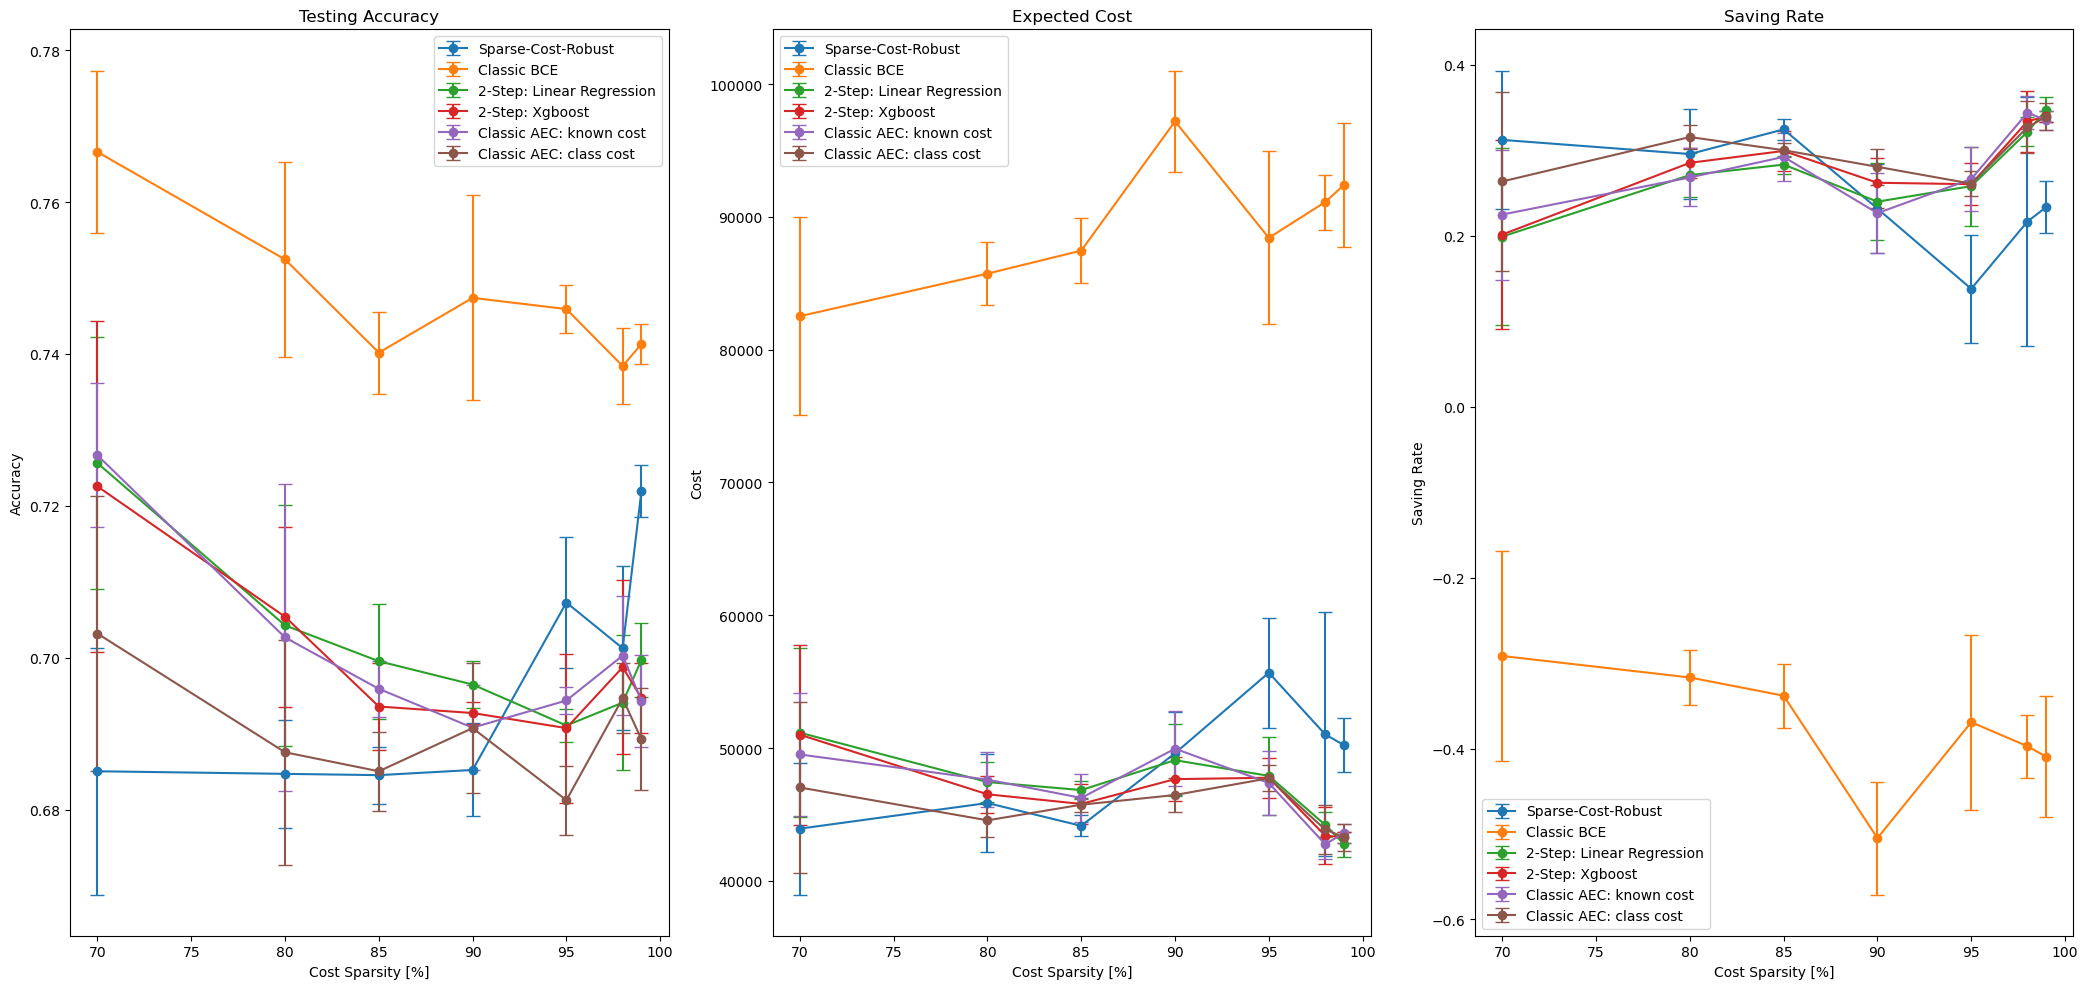

In [160]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def summarize_results(results, n_last=5):
    _, acc_vals = zip(*results["accuracy_log"][-n_last:])
    _, cost_vals = zip(*results["cost_log"][-n_last:])
    _, save_vals = zip(*results["saving_log"][-n_last:])
    return {
        "accuracy": np.mean(acc_vals),
        "expected_cost": np.mean(cost_vals),
        "saving_rate": np.mean(save_vals)
    }

################################################################
######  Experiment parameters -
######  Also possible to use this function instead:
######  set_stantard_experiment_parameters().    [See top of the Notebook]

# Hyperparameters
hyperparameters = {
    'lr' : 1e-3,
    'momentum' : 0.9,
    'batch_size' : 512,
    'num_iterations' : 7000, #13000,
    'weight_decay': 1e-5
}

# Data set selection
data_set = 'Kaggle_Telco_Customer_Churn'   # Choose:  Kaggle_Telco_Customer_Churn, tv_subscription_churn, kdd98, Kaggle_Credit_Card_Fraud, preprocess_bank_marketing
num_repeats = 5


# Ratio
testingRatio = 0.1
#ValidationRatioS = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2 ] # Equivalent of the sparsity in this case.  [0.1, 0.05, 0.02, 0.01, 0.005]
#ValidationRatioS = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.18, 0.2 ]
#ValidationRatioS = [0.005, 0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
ValidationRatioS = [0.3, 0.2, 0.15, 0.1, 0.05, 0.02, 0.01]
#ValidationRatioS = [0.4, 0.3, 0.2, 0.1, 0.05]
#ValidationRatioS = [0.005]

Sparsity = [(1 - v) * 100 for v in ValidationRatioS]

live_plotting = False
print_details = False
print_mainInfo = False
synthetic_cost = False 

noisy = False
training_noise = 0

if noisy:
  #print("in noisy")
  training_noise = 0.4 #[0, 0.3, 0.2]

  training_methods = {
      #"AEC_with_LRE": lambda: train_AEC_with_LRE(noisy_train_data_loader, val_data_loader, test_data_loader),
      "Classic_bce": lambda: train_classic_bce(noisy_train_loader_nocost, test_data_loader),
      #"Classic_AEC_known_cost": lambda: train_classic_AEC(noisy_train_data_loader, test_data_loader),
      #"Classic_AEC_combined": lambda: train_classic_AEC(noisy_combined_train_loader, test_data_loader),
      #"Classic_AEC_Only_va_set": lambda: train_classic_AEC(val_data_loader, test_data_loader),
      "Classic_W-BCE_known_cost": lambda: train_classic_WBCE(noisy_train_data_loader, test_data_loader)
    }

else:
  #print("Not noisy")
  training_methods = {
      "Sparse-Cost-Robust": lambda: train_AEC_with_LRE(train_data_loader, val_data_loader, test_data_loader),  # train_data_loader , SPB_training_loader
      "Classic BCE": lambda: train_classic_bce(train_loader_nocost, test_data_loader),
      "2-Step: Linear Regression": lambda: train_classic_AEC(train_data_loader_with_logit, test_data_loader),
      "2-Step: Xgboost": lambda: train_classic_AEC(train_data_loader_with_xgboost, test_data_loader),
      "Classic AEC: known cost": lambda: train_classic_AEC(SPB_training_loader, test_data_loader),
      "Classic AEC: class cost": lambda: train_classic_AEC(combined_train_loader, test_data_loader)  #combined
      #"Classic AEC Only val set": lambda: train_classic_AEC(val_data_loader, test_data_loader)
      #"Classic W-BCE known cost": lambda: train_classic_WBCE(train_data_loader, test_data_loader)
  }

accuracy_log = {}
# metric_log = {validationRatio: {"accuracy": [], "expected_cost": [], "saving_rate": []} for validationRatio in ValidationRatioS}
metric_log = {
    validationRatio: {
        method_name: {"accuracy": [], "expected_cost": [], "saving_rate": []}
        for method_name in training_methods
    }
    for validationRatio in ValidationRatioS
}

rmse_log = {
    validationRatio: {
        "Logistic Regression": {"rmse_total": [], "abs_rmse": [], "rel_rmse": []},
        "XGBoost": {"rmse_total": [], "abs_rmse": [], "rel_rmse": []}
    }
    for validationRatio in ValidationRatioS
}


all_results = {}



################################################################
######  Main loop for the experiment

for validationRatio in ValidationRatioS:
  print(f"Validation Ratio: {validationRatio}")

  for k in range(num_repeats):
    print(f"Repeat: {k}")

    ######  Loading and preprocessing the dataset
    if data_set == 'Kaggle_Telco_Customer_Churn':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_telco_customer_churn(eda=False)
    if data_set == 'tv_subscription_churn':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_tv_subscription_churn(eda=False)
    if data_set == 'default_credit_card':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_default_credit_card()
    if data_set == 'kdd98':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_kdd98()
    if data_set == 'Kaggle_Credit_Card_Fraud':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_credit_card_data(fixed_cost=10)
    if data_set == 'preprocess_vub_credit_scoring':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_vub_credit_scoring()
    if data_set == 'preprocess_give_me_some_credit':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_give_me_some_credit()
    if data_set == 'preprocess_bank_marketing':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_bank_marketing()
    if data_set == 'preprocess_kaggle_ieee_fraud':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_kaggle_ieee_fraud()

    (
    X_train, Y_train, cost_matrix_train,
    X_val, Y_val, cost_matrix_val,
    X_test, Y_test, cost_matrix_test,
    X_train_rebalanced, Y_train_rebalanced, cost_matrix_train_rebalanced,
    X_val_balanced, Y_val_balanced, cost_matrix_val_balanced ) = preprocessing_dataset(
        test_ratio = testingRatio,
        val_ratio = validationRatio,
        X_data = X_data,
        Y_data = Y_data,
        amounts = amounts,
        cost_matrix = cost_matrix,
        categorical_variables = categorical_variables)

    ######  Creating the data loader for the experiment
    X_tr_np     = X_train
    Y_tr_np     = Y_train.values
    C_tr_np     = cost_matrix_train

    X_val_np    = X_val
    Y_val_np    = Y_val.values
    C_val_np    = cost_matrix_val

    X_test_np    = X_test
    Y_test_np    = Y_test.values
    C_test_np    = cost_matrix_test

    X_tr_rebalanced_np = X_train_rebalanced
    Y_tr_rebalanced_np = Y_train_rebalanced
    C_tr_rebalanced_np = cost_matrix_train_rebalanced

    X_val_rebalanced_np = X_val_balanced
    Y_val_rebalanced_np = Y_val_balanced
    C_val_rebalanced_np = cost_matrix_val_balanced

    if synthetic_cost:
      print("Synthetic cost")
      C_tr_np = create_synthetic_cost_matrix(X_tr_np, C_tr_np, noise=0.1, clip_negative=True,  booster_params=None)
      C_val_np = create_synthetic_cost_matrix(X_val_np, C_val_np, noise=0.1, clip_negative=True,  booster_params=None)
      C_test_np = create_synthetic_cost_matrix(X_test_np, C_test_np, noise=0.1, clip_negative=True,  booster_params=None)


    # Classic cases
    ds_train = TensorDataset(torch.from_numpy(X_tr_np).float(), torch.from_numpy(Y_tr_np).float(), torch.from_numpy(C_tr_np).float())
    ds_val = TensorDataset(torch.from_numpy(X_val_np).float(), torch.from_numpy(Y_val_np).float(), torch.from_numpy(C_val_np).float())
    ds_test = TensorDataset(torch.from_numpy(X_test_np).float(), torch.from_numpy(Y_test_np).float(), torch.from_numpy(C_test_np).float())
    train_data_loader = DataLoader(ds_train,  batch_size=hyperparameters['batch_size'], shuffle=True)
    #val_data_loader = DataLoader(ds_val,  batch_size=hyperparameters['batch_size'], shuffle=True).
    val_data_loader = DataLoader(ds_val, batch_size=len(ds_val), shuffle=False) # Fixed validation set instead - to avoid variance between mini bacthes (probably need to do the same for training with Stratified Splits)
    test_data_loader = DataLoader(ds_test,  batch_size=hyperparameters['batch_size'], shuffle=False)

    # Special case with rebalanced validation set
    ds_train_rebalanced = TensorDataset(torch.from_numpy(X_tr_rebalanced_np).float(), torch.from_numpy(Y_tr_rebalanced_np).float(), torch.from_numpy(C_tr_rebalanced_np).float())
    ds_val_rebalanced = TensorDataset(torch.from_numpy(X_val_rebalanced_np).float(), torch.from_numpy(Y_val_rebalanced_np).float(), torch.from_numpy(C_val_rebalanced_np).float())
    train_rebalanced_loader = DataLoader(ds_train_rebalanced,  batch_size=hyperparameters['batch_size'], shuffle=True)
    val_rebalanced_loader = DataLoader(ds_val_rebalanced,  batch_size=hyperparameters['batch_size'], shuffle=True)

    # Cost-free training dataset (no cost info)
    ds_train_nocost = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float())
    train_loader_nocost = DataLoader(ds_train_nocost,batch_size=hyperparameters['batch_size'],shuffle=True)

    # Training dataset with cost based on validation set
    mean_cost_matrix = torch.from_numpy(C_val_np).float().mean(dim=0, keepdim=True)  # Mean cost matrix from validation set ; shape: (1, 2, 2)
    mean_cost_tensor = mean_cost_matrix.repeat(X_tr_np.shape[0], 1, 1)  # Fake training set with mean cost repeated; shape: (N_train, 2, 2)
    ds_train_mean_cost = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float(),mean_cost_tensor)

    combined_dataset = torch.utils.data.ConcatDataset([ds_train_mean_cost, ds_val]) # Combining both datasets (training + validation)
    combined_train_loader = DataLoader(combined_dataset,batch_size=hyperparameters['batch_size'], shuffle=True)

    # Adding noise (to validate regular LRE appraoch)
    noisy_train_loader_nocost= get_noisy_dataloader(train_loader_nocost, training_noise)
    noisy_train_data_loader = get_noisy_dataloader_with_cost(train_data_loader, training_noise)
    noisy_combined_train_loader = get_noisy_dataloader_with_cost(combined_train_loader, training_noise)

    # Estimated costs via regression
    C_tr_np_with_logit = estimate_cost_matrix_with_logit(X_val_np, C_val_np, X_tr_np)
    C_tr_np_with_xgboost = estimate_cost_matrix_with_xgboost(X_val_np, C_val_np, X_tr_np)

    ds_train_estimated_cost_with_logit = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float(),torch.from_numpy(C_tr_np_with_logit).float())
    ds_train_estimated_cost_with_xgboost = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float(),torch.from_numpy(C_tr_np_with_xgboost).float())

    train_data_loader_with_logit = DataLoader(ds_train_estimated_cost_with_logit,  batch_size=hyperparameters['batch_size'], shuffle=True)
    train_data_loader_with_xgboost = DataLoader(ds_train_estimated_cost_with_xgboost,  batch_size=hyperparameters['batch_size'], shuffle=True)

    save_dir_matrix_prediction_evaluation = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}"
    results_matrix_prediction_errors = evaluate_cost_matrix_prediction_errors(C_tr_np, C_tr_np_with_logit, C_tr_np_with_xgboost, save_dir_matrix_prediction_evaluation)

    for model_name in results_matrix_prediction_errors:
      rmse_log[validationRatio][model_name]["rmse_total"].append(results_matrix_prediction_errors[model_name]["rmse_total"])
      rmse_log[validationRatio][model_name]["abs_rmse"].append(results_matrix_prediction_errors[model_name]["abs_rmse"])
      rmse_log[validationRatio][model_name]["rel_rmse"].append(results_matrix_prediction_errors[model_name]["rel_rmse"])

    # StratifiedProportionalBatchSampler
    batch_sampler = StratifiedProportionalBatchSampler(labels=Y_tr_np, batch_size=hyperparameters['batch_size'], shuffle=True)
    SPB_training_loader = DataLoader(ds_train,batch_sampler=batch_sampler)


  ################################################################
  ######  Inner Loop for the repeat
  # for k in range(num_repeats):
  #   print(f"Repeat: {k}")

    for method_name, train_func in training_methods.items():
      print(f"  -> Training method: {method_name}")
      results = train_func()
      all_results[method_name] = results

      # Save training curve
      save_dir = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}/{method_name}"
      plot_and_save_training_curves(results, validation_ratio=validationRatio, repeat_idx=k, save_dir=save_dir)

      # Summarize results
      summary = summarize_results(results)
      for key in summary:
          metric_log[validationRatio][method_name][key].append(summary[key])

    # Save all-in-one comparison plot
    comparison_path = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}/Comparison_val{validationRatio}_repeat{k}.png"
    plot_comparison_curves(all_results, save_path=comparison_path, title_prefix=f"Cost Sparsity: {1-validationRatio} | Repeat: {k}")


# Output directory
summary_dir = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/"
os.makedirs(summary_dir, exist_ok=True)


metrics = ["accuracy", "expected_cost", "saving_rate"]
#metrics = ["accuracy", "expected_cost", "saving_rate", "rmse_total", "rmse_per_cell", "rel_rmse_per_cell"]

titles = {
    "accuracy": "Testing Accuracy",
    "expected_cost": "Expected Cost",
    "saving_rate": "Saving Rate"
}
ylabels = {
    "accuracy": "Accuracy",
    "expected_cost": "Cost",
    "saving_rate": "Saving Rate"
}

plt.figure(figsize=(21, 10))

for i, metric in enumerate(metrics):  # accuracy, expected_cost, saving_rate
    plt.subplot(1, 3, i+1)

    for method_name in training_methods:
        means = [np.mean(metric_log[val][method_name][metric]) for val in ValidationRatioS]
        stds  = [np.std(metric_log[val][method_name][metric]) for val in ValidationRatioS]

        plt.errorbar(Sparsity, means, yerr=stds, label=method_name, fmt='-o', capsize=5)

    plt.title(titles[metric])
    plt.xlabel("Cost Sparsity [%]")
    plt.ylabel(ylabels[metric])
    plt.legend()

plt.tight_layout()

plot_filename = f"{data_set}_metrics_plot.png"
plot_path = os.path.join(summary_dir, plot_filename)
plt.savefig(plot_path, dpi=600)

plt.show()

# Plain text summary 
text_path = os.path.join(summary_dir, "summary_metrics_by_validation_ratio.txt")
with open(text_path, "w") as f_txt:
    for val in ValidationRatioS:
        f_txt.write(f"\n{'='*80}\n")
        f_txt.write(f"Validation Ratio: {val}\n")
        f_txt.write(f"{'-'*80}\n")
        for method_name in training_methods:
            accs = metric_log[val][method_name]["accuracy"]
            costs = metric_log[val][method_name]["expected_cost"]
            saves = metric_log[val][method_name]["saving_rate"]

            acc_mean, acc_std = np.mean(accs), np.std(accs)
            cost_mean, cost_std = np.mean(costs), np.std(costs)
            save_mean, save_std = np.mean(saves), np.std(saves)

            f_txt.write(f"{method_name:<20} | Acc: {acc_mean:.4f} ± {acc_std:.4f}  ||  "
                        f"Cost: {cost_mean:.4f} ± {cost_std:.4f}  ||  "
                        f"Saving: {save_mean:.4f} ± {save_std:.4f}\n")

#print(f"Plain text summary saved to {text_path}")

# LaTeX table summary 
latex_path = os.path.join(summary_dir, "summary_metrics_by_validation_ratio.tex")
with open(latex_path, "w") as f_tex:
    f_tex.write("\\begin{tabular}{l l c c c}\n")
    f_tex.write("\\toprule\n")
    f_tex.write("Cost Sparsity & Method & Accuracy & Cost & Saving Rate \\\\\n")
    f_tex.write("\\midrule\n")

    for idx, val in enumerate(ValidationRatioS):
        for method_name in training_methods:
            accs = metric_log[val][method_name]["accuracy"]
            costs = metric_log[val][method_name]["expected_cost"]
            saves = metric_log[val][method_name]["saving_rate"]
            sparsity = Sparsity[idx]

            acc_mean, acc_std = np.mean(accs), np.std(accs)
            cost_mean, cost_std = np.mean(costs), np.std(costs)
            save_mean, save_std = np.mean(saves), np.std(saves)

            f_tex.write(
                f"{sparsity:.0f}\%  & {method_name} & "
                f"{acc_mean:.4f} $\\pm$ {acc_std:.4f} & "
                f"{cost_mean:.4f} $\\pm$ {cost_std:.4f} & "
                f"{save_mean:.4f} $\\pm$ {save_std:.4f} \\\\\n"
            )

        if idx < len(ValidationRatioS) - 1:
            f_tex.write("\\midrule\n")

    f_tex.write("\\bottomrule\n")
    f_tex.write("\\end{tabular}\n")

#print(f"LaTeX table saved to {latex_path}")

# RMSE summary: plain text 
rmse_path = os.path.join(summary_dir, "summary_rmse_by_validation_ratio.txt")
with open(rmse_path, "w") as f_rmse:
    for val in ValidationRatioS:
        f_rmse.write(f"\n{'='*80}\n")
        f_rmse.write(f"Validation Ratio: {val}\n")
        f_rmse.write(f"{'-'*80}\n")
        for model_name in rmse_log[val]:
            total_rmse_vals = rmse_log[val][model_name]["rmse_total"]
            abs_rmse_vals = rmse_log[val][model_name]["abs_rmse"]
            rel_rmse_vals = rmse_log[val][model_name]["rel_rmse"]

            total_rmse_mean, total_rmse_std = np.mean(total_rmse_vals), np.std(total_rmse_vals)
            abs_rmse_mean, abs_rmse_std = np.mean(abs_rmse_vals), np.std(abs_rmse_vals)
            rel_rmse_mean, rel_rmse_std = np.mean(rel_rmse_vals), np.std(rel_rmse_vals)

            f_rmse.write(f"{model_name:<20} | RMSE: {total_rmse_mean:.4f} ± {total_rmse_std:.4f}  ||  "
                         f"Abs-RMSE: {abs_rmse_mean:.4f} ± {abs_rmse_std:.4f}  ||  "
                         f"Rel-RMSE: {rel_rmse_mean:.4f} ± {rel_rmse_std:.4f}\n")

#print(f"RMSE summary saved to {rmse_path}")

# RMSE summary: LaTeX 
latex_rmse_path = os.path.join(summary_dir, "summary_rmse_by_validation_ratio.tex")
with open(latex_rmse_path, "w") as f_latex_rmse:
    f_latex_rmse.write("\\begin{tabular}{l l c c c}\n")
    f_latex_rmse.write("\\toprule\n")
    f_latex_rmse.write("Cost Sparsity & Model & RMSE & Abs RMSE & Rel RMSE \\\\\n")
    f_latex_rmse.write("\\midrule\n")

    for idx, val in enumerate(ValidationRatioS):
        sparsity = Sparsity[idx]

        for model_name in rmse_log[val]:
            total_rmse_vals = rmse_log[val][model_name]["rmse_total"]
            abs_rmse_vals = rmse_log[val][model_name]["abs_rmse"]
            rel_rmse_vals = rmse_log[val][model_name]["rel_rmse"]

            total_rmse_mean, total_rmse_std = np.mean(total_rmse_vals), np.std(total_rmse_vals)
            abs_rmse_mean, abs_rmse_std = np.mean(abs_rmse_vals), np.std(abs_rmse_vals)
            rel_rmse_mean, rel_rmse_std = np.mean(rel_rmse_vals), np.std(rel_rmse_vals)

            f_latex_rmse.write(
                f"{sparsity:.0f}\\% & {model_name} & "
                f"{total_rmse_mean:.4f} $\\pm$ {total_rmse_std:.4f} & "
                f"{abs_rmse_mean:.4f} $\\pm$ {abs_rmse_std:.4f} & "
                f"{rel_rmse_mean:.4f} $\\pm$ {rel_rmse_std:.4f} \\\\\n"
            )

        if idx < len(ValidationRatioS) - 1:
            f_latex_rmse.write("\\midrule\n")

    f_latex_rmse.write("\\bottomrule\n")
    f_latex_rmse.write("\\end{tabular}\n")

#print(f"LaTeX RMSE table saved to {latex_rmse_path}")



